In [ ]:
# Pruebas de conexiones a BQ y MySql local (def)

from google.cloud import bigquery
from google.oauth2 import service_account
from google.colab import auth
auth.authenticate_user()
client = bigquery.Client(project='sprint3-analytics-cristina-f-t')



ModuleNotFoundError: No module named 'google.cloud'

In [ ]:
sql_query = """select * from sprint3_gold.product_sales_ranking"""
query_results = client.query(sql_query).result().to_dataframe()

In [ ]:
display(query_results)

Ejecutar en la terminal local para inicializar el servicio, debe mantenerse activo mientras se use:  


py -m notebook --no-browser --NotebookApp.allow_origin="https://colab.research.google.com" --NotebookApp.allow_credentials=True --port=8888 --NotebookApp.port_retries=0

- Esta linea cambia a cada ejecucion del codigo superior, y se debe actualizar en la conexion a local de colab:  
http://127.0.0.1:8888/tree?token=bf9ca177ad035dc1982227b13034902b22af627c78dfec32

In [2]:
from sqlalchemy import create_engine
import pandas as pd

USER = "ruser"
PASSWORD = "2026Ruser1."
HOST = "127.0.0.1"
PORT = "3306"
DATABASE = "sales"

DATABASE_URI = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(DATABASE_URI)

# Nivell 1 - Visualització analítica guiada en Python

L'objectiu del nivell és aplicar criteri analític per responderé preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del model del Sprint 2 a partir de l’exercici 8, carregades com a DataFrame independents.

En aquest nivell no es demana construir un dataset final ni unificar totes les taules, sinó:

» Identificar quina informació és necessària.

» Escollir correctament la taula (o taules) rellevant(s).

» Construir visualitzacions adequades.

» Interpretar els resultats obtinguts.

Aquest nivell posa l'èmfasi en pensar abans de programar.

# Cargamos las tablas como dataframes independientes

In [3]:
# La tabla Transactions aunque ya la tenemos cargada
query = "SELECT * FROM transactions;"
df_transactions = pd.read_sql(query, con=engine)
# Tabla companies
query = "SELECT * FROM companies;"
df_companies = pd.read_sql(query, con=engine)
# Tabla credit_cards
query = "SELECT * FROM credit_cards;"
df_credit_cards = pd.read_sql(query, con=engine)
# Tabla users
query = "SELECT * FROM users;"
df_users = pd.read_sql(query, con=engine)
# Tabla products
query = "SELECT * FROM products;"
df_products = pd.read_sql(query, con=engine)

## Exercici 1: Preguntes analítiques directes (sense integracions complexes)
🌍 Context: Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

+ Aspectes a revisar i analitzar:

» Identificar quina informació és necessària

Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

Preguntes analítiques: (només utilitzant la taula de transaccions) :

### 1.1 Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

Selecciona la columna temporal adequada.  
Defineix el nivell temporal d'anàlisi.

Compta el nombre de registres per període temporal.  
Ordena els resultats cronològicament.  
Visualitza l'evolució amb un gràfic de línies amb pandas.  

- Per a cada pregunta: Construeix una visualització senzilla en Python sense utilitzar IA.
- Interpreta breument el resultat obtingut.
- Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
- Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

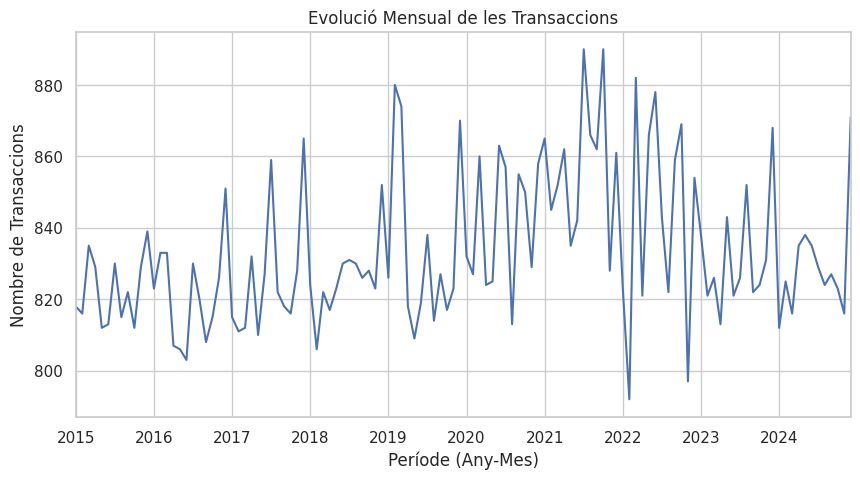

In [28]:
import matplotlib.pyplot as plt

# Elegimos la tabla/df de transacciones

# Nos aseguramos que el campo sea 'datetime'
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])

# Agrupamos por mes y contamos en número de transacciones
transaccions_mensuals = df_transactions.groupby(df_transactions['timestamp'].dt.to_period('M')).size()

# Ordenamos los resultados cronológicamente (Paso explícito)
transaccions_mensuals = transaccions_mensuals.sort_index()

# Dibujamos el gráfico de líneas de Pandas
transaccions_mensuals.plot(kind='line', figsize=(10, 5), title="Evolució Mensual de les Transaccions")
plt.xlabel("Període (Any-Mes)")
plt.ylabel("Nombre de Transaccions")
plt.show()

#### Interpretación

* **Estabilidad operativa:** El volumen mensual oscila de manera muy estable entre **~790 y ~890 transacciones mensuales** a lo largo de los 10 años, sin mostrar una tendencia estructural claramente ascendente o descendente a largo plazo.

#### Resultado propuesto por la IA :


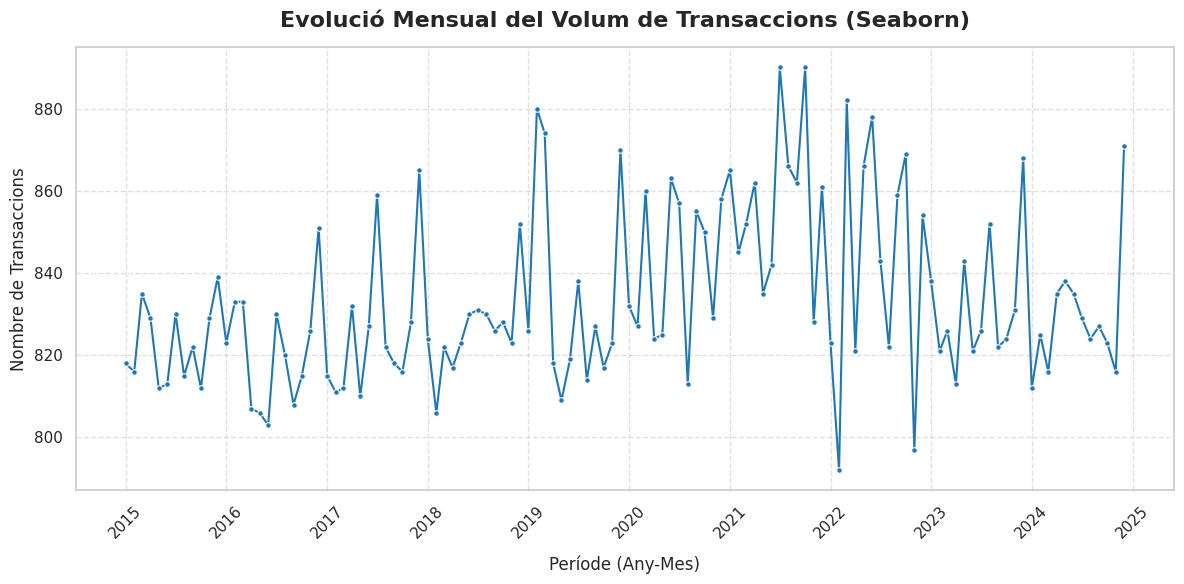

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the Series to a DataFrame for easier plotting with seaborn
df_monthly_transactions = transaccions_mensuals.reset_index()
df_monthly_transactions.columns = ['Month', 'Transactions']

# Convert 'Month' back to datetime for proper x-axis scaling in seaborn
df_monthly_transactions['Month'] = pd.to_datetime(df_monthly_transactions['Month'].astype(str))

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Transactions', data=df_monthly_transactions, marker='o', markersize=4, color='#1f77b4')

plt.title('Evolució Mensual del Volum de Transaccions (Seaborn)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Període (Any-Mes)', fontsize=12, labelpad=10)
plt.ylabel('Nombre de Transaccions', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Improve x-axis date formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Vemos que la IA ha elegido igualmente un gráfico de líneas
---
#### Comparativa entre gráficos y valoración crítica

Al comparar la visualización generada manualmente con Matplotlib frente a la propuesta mediante la IA (Seaborn), se identifican los siguientes puntos de mejora:

* **Inclusión de marcadores:** El gráfico de Seaborn añade puntos en cada observación mensual, lo que permite identificar el valor exacto de cada mes de forma más precisa que la línea continua original.
* **Legibilidad del eje temporal:** La rotación del texto en las fechas del eje X evita que los años se solapen, facilitando la lectura del gráfico.
* **Carga visual (Grid):** El uso de una cuadrícula discontinua y más tenue en la versión con IA ayuda a centrar la atención en la tendencia de los datos y no en la retícula de fondo.

**Conclusión:** La propuesta generada con la IA supone una **leve mejora respecto al gráfico base**, ya que optimiza el diseño estético y mejora la precisión analítica de los datos sin recargar la imagen.

### 1.2 Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.

Identifica la columna que representa el usuari.  
Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.  
Ordena els usuaris de major a menor volum de facturació.  
Selecciona els N usuaris principals (per exemple, els 15 primers).  
Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn  

#### Pasos Guiados y Código Python (con Seaborn)

Siguiendo la metodología requerida:

* **Identificar la columna:** Usamos `user_id` para identificar al usuario y `amount` para el importe económico.

* **Agrupar y sumar:** Agrupamos con `groupby('user_id')['amount'].sum()`.

* **Ordenar:** Aplicamos `.sort_values(ascending=False)` para ordenar de mayor a menor.

* **Filtrar N principales:** Tomamos el `head(15)`.

* **Visualizar:** Usamos un pie chart para mostrar la relacion de la facturacion de los Top15 con la facturación total y un gráfico de barras para mostrar solo la facturación de los Top15

In [7]:
# Seleccionar solo las transacciones no declinadas
df_valid = df_transactions[df_transactions['declined'] == 0]

# Agrupar por user_id y sumar amount
top_users = df_valid.groupby('user_id')['amount'].sum().reset_index()

# Ordenar de mayor a menor
top_users = top_users.sort_values(by='amount', ascending=False)

# Seleccionar los top 15
top_15_users = top_users.head(15)

print("Top 15 usuarios por facturación:")
print(top_15_users)

Top 15 usuarios por facturación:
     user_id    amount
288      289  47332.90
317      318  46393.44
454      455  40594.55
416      417  37393.91
184      185  34560.87
284      285  33217.28
453      454  29528.42
348      349  27835.38
192      193  27076.83
316      317  22484.76
387      388  20784.26
442      443  20605.24
318      319  20455.52
392      393  19154.68
436      437  18149.45


Facturación Total Global: 29,025,382.41 €
Número Total de Usuarios Activos: 5000
Facturación Acumulada Top 15 Usuarios: 445,567.49 € (1.54% del total)


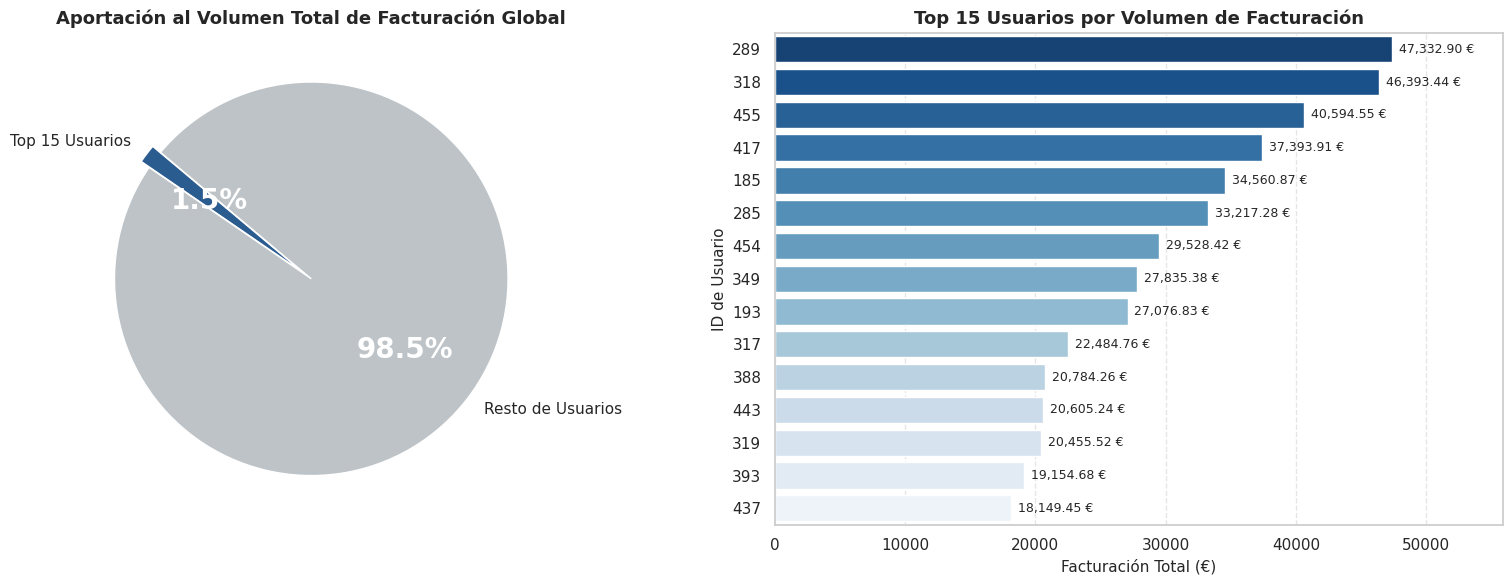

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Seleccionar solo las transacciones no declinadas
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Agrupar por usuario y calcular el volumen total por usuario
facturacion_usuarios = (
    df_valid.groupby('user_id')['amount']
    .sum()
    .reset_index()
    .sort_values(by='amount', ascending=False)
)

# Cálculo de métricas
facturacion_total_global = facturacion_usuarios['amount'].sum()
total_usuarios_activos = facturacion_usuarios['user_id'].nunique()

# Seleccionar los 15 usuarios principales
top_15_users = facturacion_usuarios.head(15).copy()
top_15_users['user_id'] = top_15_users['user_id'].astype(str)

facturacion_top_15 = top_15_users['amount'].sum()
pct_top_15 = (facturacion_top_15 / facturacion_total_global) * 100

print(f'Facturación Total Global: {facturacion_total_global:,.2f} €')
print(f'Número Total de Usuarios Activos: {total_usuarios_activos}')
print(
    f'Facturación Acumulada Top 15 Usuarios: {facturacion_top_15:,.2f} €'
    f' ({pct_top_15:.2f}% del total)'
)

# VISUALIZACIÓN COMPUESTA (Volumen Total vs Top 15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Proporción del Volumen de Facturación (Top 15 vs Resto)
resto_facturacion = facturacion_total_global - facturacion_top_15
datos_pie = [facturacion_top_15, resto_facturacion]
etiquetas_pie = ['Top 15 Usuarios', 'Resto de Usuarios']

# Capturamos los elementos del gráfico (wedges, texts, autotexts)
wedges, texts, autotexts = axes[0].pie(
    datos_pie,
    labels=etiquetas_pie,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2b5c8f', '#bdc3c7'],
    explode=(0.05, 0),
)

# Cambiamos el color a blanco (por defecto es negro), negrita y fuente más grande para mejor legibilidad
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(20)

axes[0].set_title(
    'Aportación al Volumen Total de Facturación Global',
    fontsize=13,
    fontweight='bold',
)

# Gráfico B: Ranking de los Top 15 Usuarios
sns.barplot(
    data=top_15_users,
    x='amount',
    y='user_id',
    ax=axes[1],
    palette='Blues_r',
    hue='user_id',
    legend=False,
)

# Añadimos las etiquetas de total por usuario
for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt='{:,.2f} €',  # Formato numérico con decimales y símbolo €
        padding=5,        # Espaciado respecto a la barra
        fontsize=9,
    )

# Ajuste del límite X para que el texto de la barra más larga no se corte
axes[1].set_xlim(0, top_15_users['amount'].max() * 1.18)

axes[1].set_title(
    'Top 15 Usuarios por Volumen de Facturación',
    fontsize=13,
    fontweight='bold',
)
axes[1].set_xlabel('Facturación Total (€)', fontsize=11)
axes[1].set_ylabel('ID de Usuario', fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Interpretación del Resultado

* **Líderes de facturación:** Los usuarios con `user_id` **289** y **318** encabezan el ranking con un volumen acumulado muy similar, alrededor de los **47.000 €**.

* **Distribución:** Existe una diferencia notable dentro del propio Top 15: el primer usuario duplica ampliamente la facturación del usuario en la posición 15 (`user_id` **437**, con **18149.45 €**). Esto muestra una alta concentración de ingresos en un grupo reducido de usuarios clave (*power users*).

#### Propuesta de la IA

In [40]:
!pip install squarify

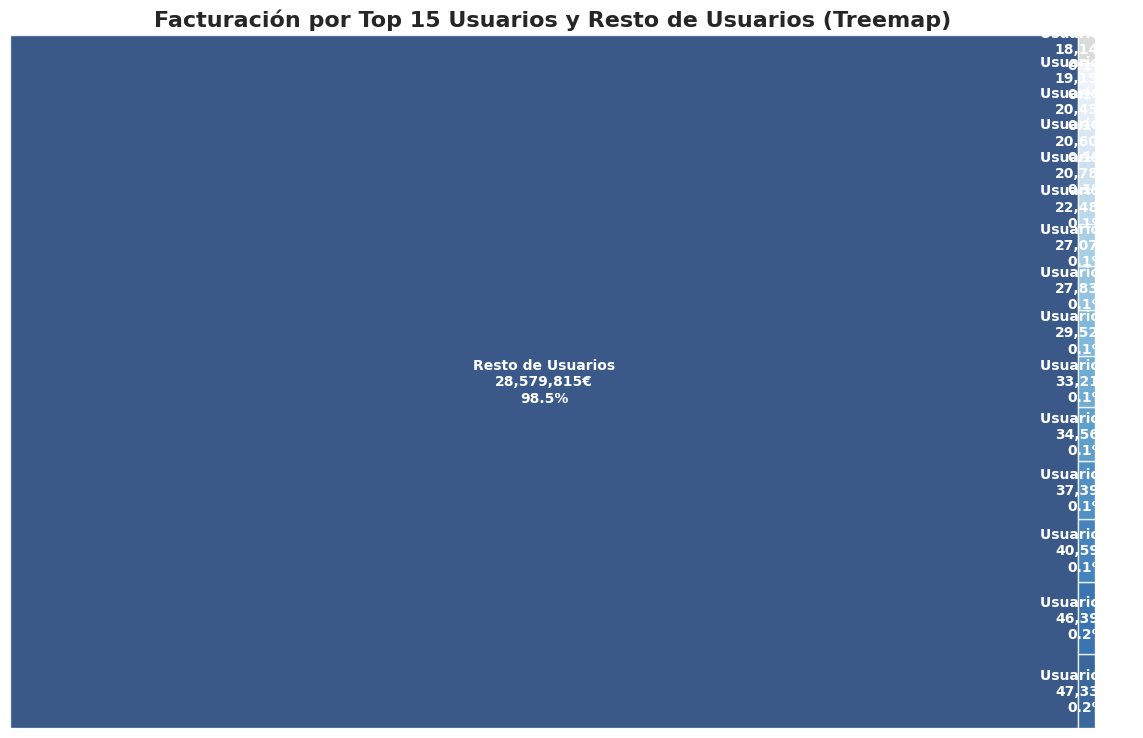

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import squarify
import matplotlib.colors as mcolors

# 1. Recalculate top_15_users and total billing from df_transactions
#    (as done in previous cells to ensure consistency)
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Group by user_id and sum amount
user_billing = df_valid.groupby('user_id')['amount'].sum().reset_index()

# Sort by amount and get top 15
top_15_users_df = user_billing.sort_values(by='amount', ascending=False).head(15)

# Calculate total global billing
total_billing_global = user_billing['amount'].sum()

# Calculate billing for the top 15 users
billing_top_15 = top_15_users_df['amount'].sum()

# Calculate billing for the rest of the users
billing_rest = total_billing_global - billing_top_15

# Prepare data for the treemap
# Combine top 15 users and the 'Rest of Users'
treemap_data_list = []
for index, row in top_15_users_df.iterrows():
    treemap_data_list.append({'category': f"Usuario {int(row['user_id'])}", 'amount': row['amount']})

treemap_data_list.append({'category': 'Resto de Usuarios', 'amount': billing_rest})

treemap_df = pd.DataFrame(treemap_data_list)

# Sort data for better visualization, largest first
treemap_df = treemap_df.sort_values(by='amount', ascending=False).reset_index(drop=True)

# Create labels with category, amount, and percentage
labels = []
for index, row in treemap_df.iterrows():
    percentage = (row['amount'] / total_billing_global) * 100
    labels.append(f"{row['category']}\n{row['amount']:,.0f}€\n{percentage:.1f}%")

# Define colors for the treemap
# Using a colormap for the top users and a distinct color for 'Resto de Usuarios'
num_top_users = len(top_15_users_df)
cmap = plt.cm.Blues_r # Reverse Blues colormap for a darker to lighter gradient
norm = mcolors.Normalize(vmin=0, vmax=num_top_users)

colors = [cmap(norm(i)) for i in range(num_top_users)]
colors.append('lightgray') # Color for 'Resto de Usuarios'

# Create the treemap
plt.figure(figsize=(14, 9)) # Adjust figure size for better readability
squarify.plot(sizes=treemap_df['amount'], label=labels, color=colors, alpha=.8,
              text_kwargs={'fontsize':10, 'color':'white', 'fontweight':'bold'})
plt.title("Facturación por Top 15 Usuarios y Resto de Usuarios (Treemap)", fontsize=16, fontweight='bold')
plt.axis('off') # Hide axes
plt.show()

##### Esta propuesta de Treemap IA no mejora en absoluto la visibilidad de los Top15, pedimos otra solo con los Top15

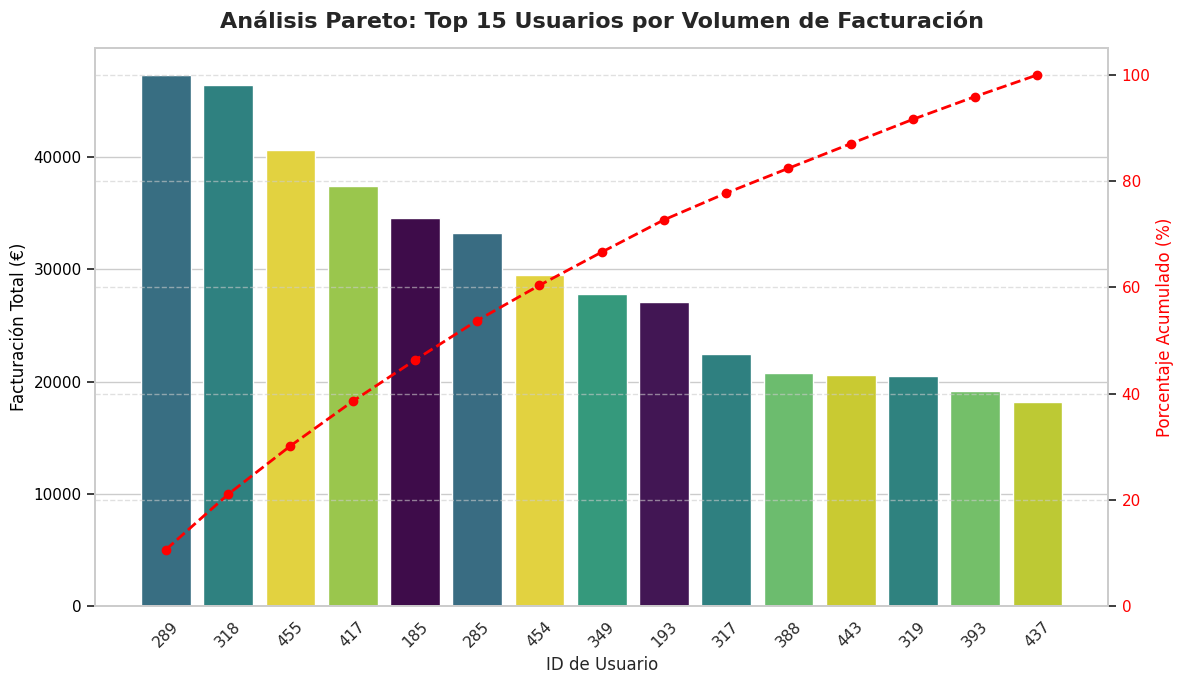

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure top_15_users is sorted by amount (already done in previous steps)
top_15_users = top_users.head(15).copy()

# Calculate cumulative sum and percentage
total_amount_top15 = top_15_users['amount'].sum()
top_15_users['cumulative_amount'] = top_15_users['amount'].cumsum()
top_15_users['cumulative_percentage'] = (top_15_users['cumulative_amount'] / total_amount_top15) * 100

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart for individual amounts
sns.barplot(
    x=top_15_users['user_id'].astype(str),
    y='amount',
    data=top_15_users,
    palette='viridis',
    hue='user_id', # Add hue to suppress the FutureWarning
    legend=False,  # Set legend to False as the hue is redundant for individual bars
    ax=ax1
)
ax1.set_xlabel('ID de Usuario', fontsize=12)
ax1.set_ylabel('Facturación Total (€)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('Análisis Pareto: Top 15 Usuarios por Volumen de Facturación', fontsize=16, pad=15, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Create a second y-axis for the cumulative percentage
ax2 = ax1.twinx()
ax2.plot(
    top_15_users['user_id'].astype(str),
    top_15_users['cumulative_percentage'],
    color='red',
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Porcentaje Acumulado'
)
ax2.set_ylabel('Porcentaje Acumulado (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # Adjust y-axis limit for percentage

# Add cumulative percentage labels on the line
for index, row in top_15_users.iterrows():
    ax2.annotate(f'{row["cumulative_percentage"]: .1f}%',
                 xy=(index, row['cumulative_percentage']),
                 xytext=(5, 5),
                 textcoords='offset points',
                 color='red',
                 fontsize=9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Comparación y Valoración Crítica (Propuesta de la IA)

* **Propuesta de la IA:** Gráfico de Pareto (*barras verticales de facturación combinadas con una línea roja de porcentaje acumulado en el eje secundario*).
* **Valoración:** **Mejora sustancial.** En cuanto a la visualizacion, pese a que **no tiene en cuenta la Facturacion Total**, sino solamente el total de los Top15, pero el gráfico es bonito.

---

### Razones de la Valoración

* **Aporte analítico:** A diferencia de una simple gráfica de barras, el gráfico de Pareto introduce una perspectiva de negocio clave (*el principio del 80/20*). Permite identificar visualmente qué proporción de la facturación total de este grupo concentran los primeros usuarios.

* **Claridad visual:** El uso del doble eje (**Y₁** para importe en euros e **Y₂** para porcentaje acumulado) añade una segunda capa de información útil sin recargar en exceso la imagen.

* **Punto menor a mejorar:** Al cambiar a formato vertical, los identificadores del eje X (*289, 318...*) requieren rotación a 45° para no solaparse, pero sigue siendo perfectamente legible al tratarse solo de 15 elementos.

### 1.3 Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades?** Exemple de passos guiats amb seaborn.

Crea una nova columna amb l'hora del dia a partir del timestamp.  
Utilitza un violinplot de seaborn per analitzar la distribució dels imports.  
Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.  
Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.  

#### Pasos Guiados y Código Python (con Seaborn)

* **Nueva columna de hora:** Extraemos la hora del *timestamp* usando `.dt.hour`.

* **Configuración del Violinplot:** Utilizamos la función `sns.violinplot`.

* **Asignación de ejes:** Definimos `x='hour'` para el tiempo, `y='amount'` para los importes y `hue='status_label'` para separar el estado de la transacción.

* **Parámetros clave:**
  * `split=True`: Divide el violín en dos mitades para comparar directamente aceptadas vs. rechazadas.
  * `inner='quartile'`: Muestra la mediana y los cuartiles dentro de la propia distribución.

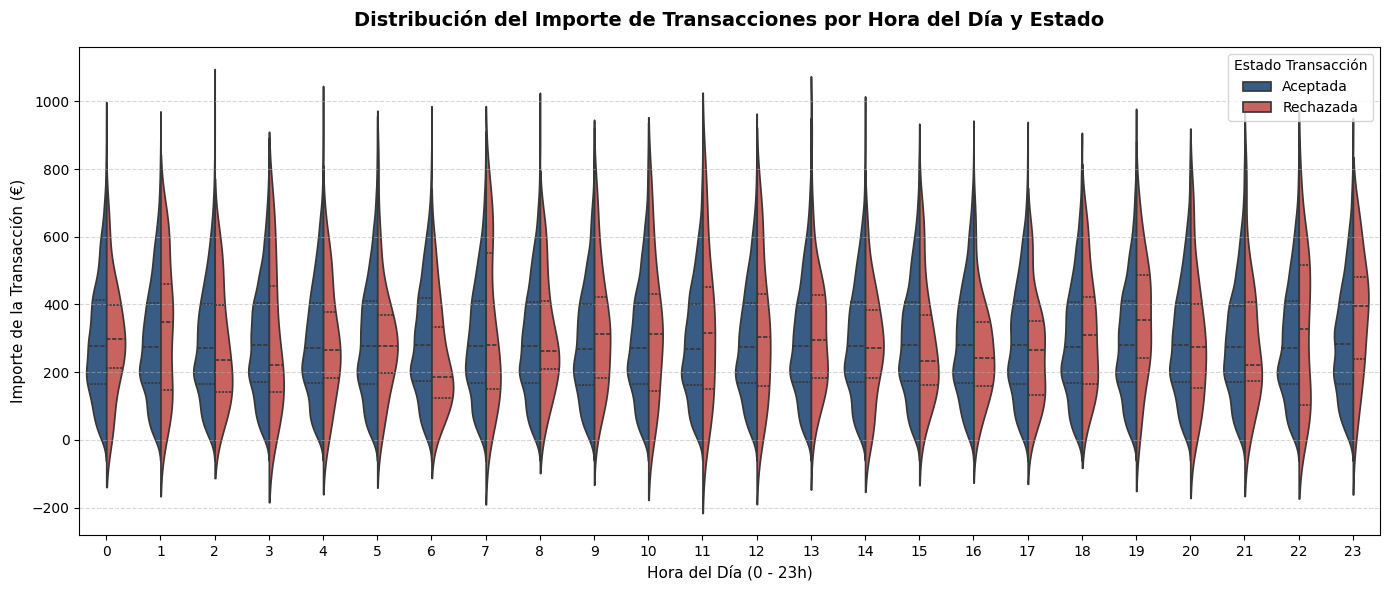

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la columna con la hora del día
df_transactions['hour'] = df_transactions['timestamp'].dt.hour

# Crear una etiqueta legible para el estado (0: Aceptada, 1: Rechazada)
df_transactions['status_label'] = df_transactions['declined'].map(
    {0: 'Aceptada', 1: 'Rechazada'}
)

# Representación mediante violinplot con split e inner quartile
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=df_transactions,
    x='hour',
    y='amount',
    hue='status_label',
    split=True,
    inner='quartile',
    palette={'Aceptada': '#2b5c8f', 'Rechazada': '#d9534f'},
)

plt.title(
    'Distribución del Importe de Transacciones por Hora del Día y Estado',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Hora del Día (0 - 23h)', fontsize=11)
plt.ylabel('Importe de la Transacción (€)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Estado Transacción')

plt.tight_layout()
plt.show()

#### Interpretación del Resultado

* **Distribución por horas:** La mediana y la dispersión del importe se mantienen bastantes parejas durante las 24 horas del día.

* **Aceptadas vs. Rechazadas:**
  * No hay diferencias claras en la mediana entre las operaciones aceptadas y rechazadas a ninguna hora en concreto.
  * Ambas muestran una ligera asimetría positiva (*la mayoría de transacciones se concentran entre 100€ y 400€, con una cola que se extiende hacia valores más altos cerca de los 1000€*).

* **Conclusión:** La hora del día no influye de forma clara ni en el importe medio de la compra ni en que la transacción sea rechazada.

#### Propuesta de la IA

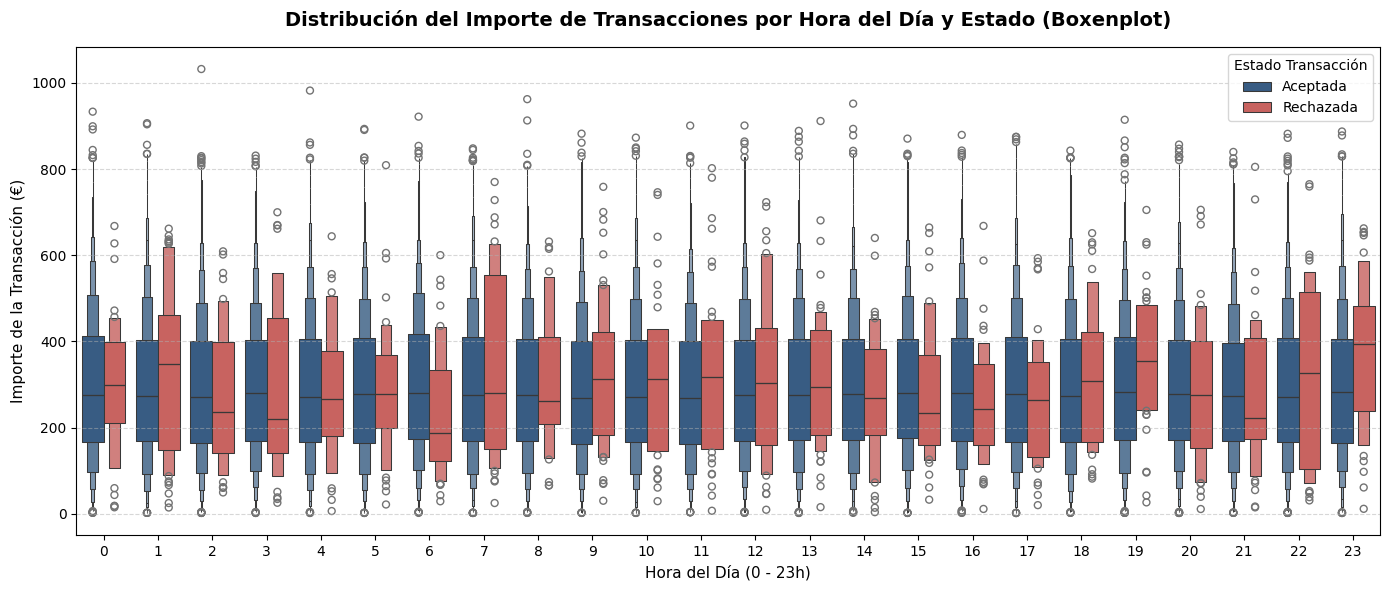

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'hour' and 'status_label' columns are available (assuming they were created previously)
df_transactions['hour'] = df_transactions['timestamp'].dt.hour
df_transactions['status_label'] = df_transactions['declined'].map({0: 'Aceptada', 1: 'Rechazada'})

plt.figure(figsize=(14, 6))
sns.boxenplot(
    data=df_transactions,
    x='hour',
    y='amount',
    hue='status_label',
    palette={'Aceptada': '#2b5c8f', 'Rechazada': '#d9534f'}
)

plt.title(
    'Distribución del Importe de Transacciones por Hora del Día y Estado (Boxenplot)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Hora del Día (0 - 23h)', fontsize=11)
plt.ylabel('Importe de la Transacción (€)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Estado Transacción')

plt.tight_layout()
plt.show()

#### Comparación y Valoración Crítica (Propuesta de la IA)

* **Propuesta de la IA:** Uso de un Boxenplot (`sns.boxenplot`) agrupando por hora y dividiendo según el estado de la transacción.

* **Valoración:** **Pérdida de claridad respecto a la opción inicial.**

---

### Razones de la Valoración

* **Saturación visual:** Al meter 24 horas con 2 categorías cada una, se juntan 48 cajas escalonadas llenas de niveles y puntos atípicos (*outliers*). Esto genera mucho ruido y complica ver las tendencias de un vistazo.

* **Violinplot vs. Boxenplot:** Nuestro Violinplot inicial con `split=True` junta ambas distribuciones (*aceptadas y rechazadas*) en una sola figura por hora, lo que hace la comparación inmediata. El Boxenplot las separa en cajas contiguas, duplicando el espacio horizontal y recargando el gráfico sin necesidad.

### 1.4 Quins dies de la setmana es concentra més activitat de venda?  
- Per a cada pregunta: Construeix una visualització senzilla en Python sense utilitzar IA.
- Interpreta breument el resultat obtingut.
- Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
- Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

#### Pasos Guiados y Código  (con Seaborn)

 **Extraer el día de la semana:** Convertimos la columna `timestamp` a tipo `datetime` y extraemos el día con `.dt.day_name()`.

 **Mapear y ordenar:** Traducimos los nombres de los días al castellano y aplicamos un orden cronológico lógico (de Lunes a Domingo).

 **Agrupar y sumar:** Agrupamos las transacciones no declinadas por día de la semana y sumamos el importe (`amount`).

 **Visualizar:** Generamos un gráfico de barras y heatmap según el `amount` con Seaborn.

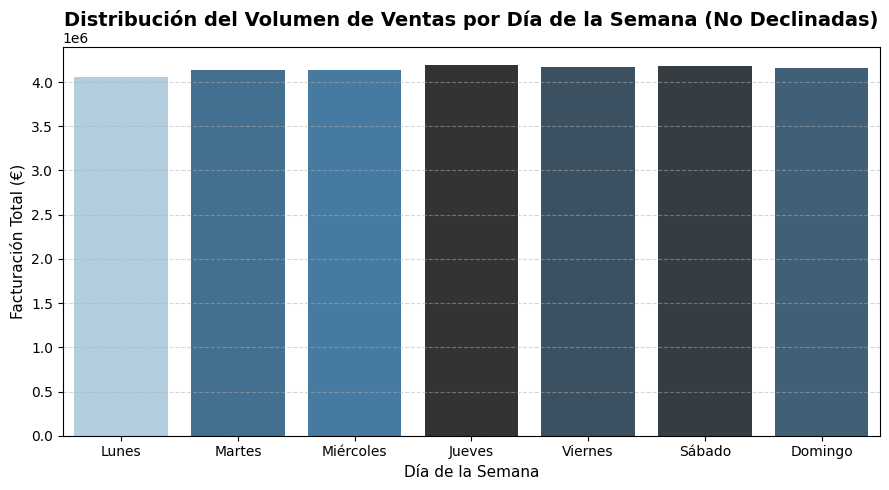

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapeo de nombres de días al castellano y definición del orden semanal
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}
orden_dias = [
    'Lunes',
    'Martes',
    'Miércoles',
    'Jueves',
    'Viernes',
    'Sábado',
    'Domingo',
]

# Crear la columna traducida
df_transactions['dia_semana'] = (
    df_transactions['timestamp'].dt.day_name().map(dias_es)
)

# Filtrar transacciones no declinadas
df_non_declined = df_transactions[df_transactions['declined'] == 0]

# Agrupar por día de la semana y sumar la facturación total de transacciones no declinadas
ventas_por_dia_no_declinadas = (
    df_non_declined.groupby('dia_semana')['amount']
    .sum()
    .reindex(orden_dias)
    .reset_index()
)

# Representación mediante gráfico de barras con Seaborn
plt.figure(figsize=(9, 5))
sns.barplot(
    data=ventas_por_dia_no_declinadas,
    x='dia_semana',
    y='amount',
    hue='amount',
    palette='Blues_d',
    legend=False,
)

plt.title(
    'Distribución del Volumen de Ventas por Día de la Semana (No Declinadas)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Día de la Semana', fontsize=11)
plt.ylabel('Facturación Total (€)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Interpretación del Resultado

* **Distribución uniforme:** El volumen de facturación se mantiene de forma prácticamente constante a lo largo de los siete días de la semana, representando cada día alrededor del **14% del total acumulado**.

* **Sin estacionalidad semanal clara:** No se observa un único día de la semana que concentre un pico de ventas desproporcionado ni tampoco jornadas con caídas drásticas de actividad, lo que sugiere un hábito de consumo continuo tanto en días laborables como en fin de semana.

* **Destacando:**
  * **Menores ventas:** los Lunes.
  * **Mayores ventas:** los Jueves y Sábados.

#### Propuesta 1 de la IA

La primera propuesta de la IA ha sido prácticamente igual salvo en los colores de las barras y el total por día

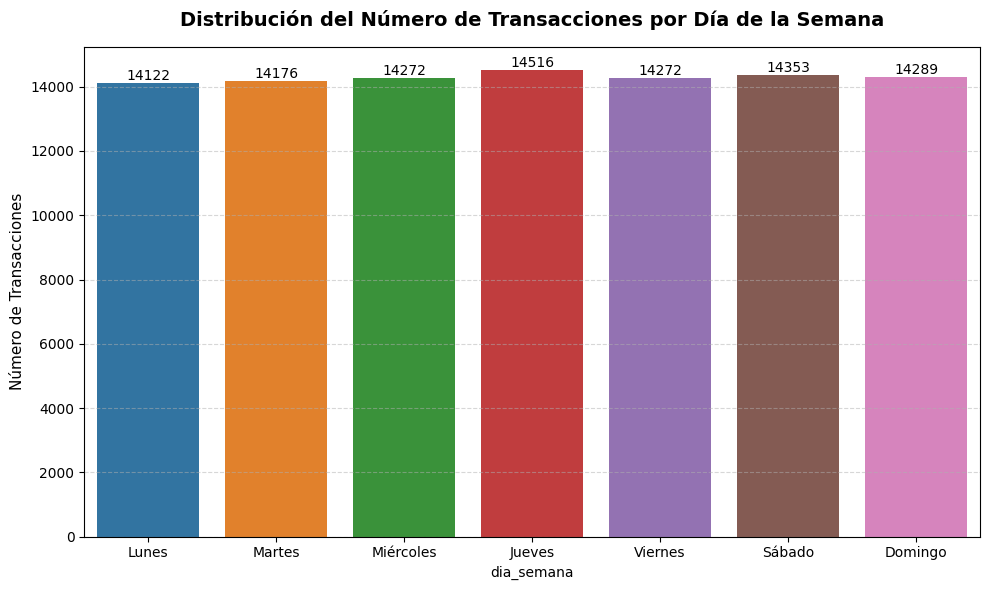

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar el formato datetime en la columna temporal (ya hecho en celdas anteriores)
# df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])

# Mapeo de nombres de días al castellano y definición del orden semanal (ya definido en celdas anteriores)
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}
orden_dias = [
    'Lunes',
    'Martes',
    'Miércoles',
    'Jueves',
    'Viernes',
    'Sábado',
    'Domingo',
]

# Crear la columna traducida 'dia_semana' si no existe (ya hecha en celdas anteriores)
# df_transactions['dia_semana'] = df_transactions['timestamp'].dt.day_name().map(dias_es)

# Agrupar por día de la semana y contar el número de transacciones
transacciones_por_dia = (
    df_transactions.groupby('dia_semana').size()
    .reindex(orden_dias)
    .reset_index(name='num_transacciones')
)

# Representación mediante gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=transacciones_por_dia,
    x='dia_semana',
    y='num_transacciones',
    hue='dia_semana',
    palette='tab10',
    legend=False,
)

plt.title(
    'Distribución del Número de Transacciones por Día de la Semana',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.ylabel('Número de Transacciones', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de valor en la parte superior de cada barra
for index, row in transacciones_por_dia.iterrows():
    plt.text(index, row['num_transacciones'], f'{row['num_transacciones']}', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

#### Propuesta 2 IA
Le he pedido otro gráfico diferente y ha propuesto un gráfico circular que **no mejora** la visibilidad que tenemos actualmente con el gráfico de barras

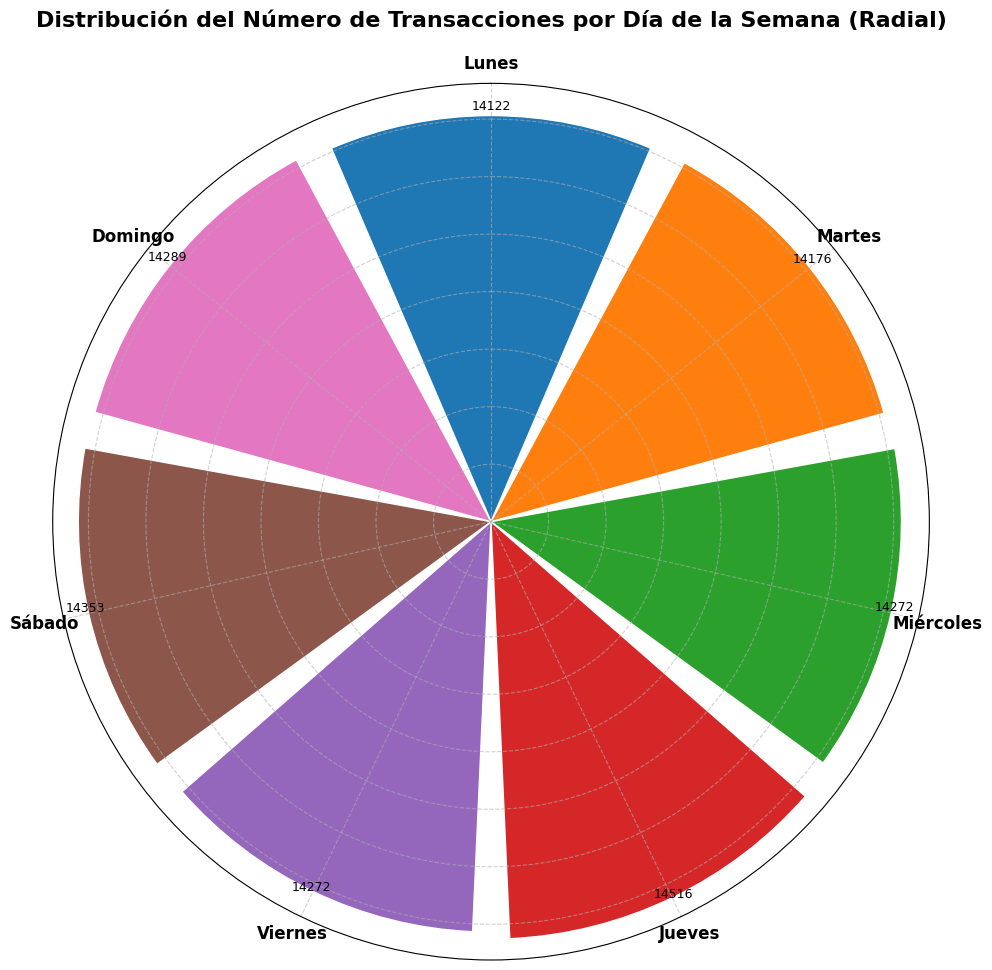

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'transacciones_por_dia' is sorted by 'orden_dias' (already done in previous steps)
# 'transacciones_por_dia' already contains 'dia_semana' and 'num_transacciones'

# Number of days
num_days = len(orden_dias)

# Create angles for each day, assuming full circle (2*pi)
angles = np.linspace(0, 2 * np.pi, num_days, endpoint=False).tolist()

# Add the first day to the end to close the circle if needed, but for bars, it's usually handled by width
# For radial bars, we often add the first element at the end to create a closed loop visually
# However, for discrete bars, it's better to just plot the num_days bars.

# The height of each bar (number of transactions)
heights = transacciones_por_dia['num_transacciones'].tolist()

# Set up the polar plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Bar width (adjust as needed, typically 2*pi / num_days)
bar_width = 2 * np.pi / num_days * 0.9 # 90% of the available angular space

# Plot the bars
bars = ax.bar(angles, heights, width=bar_width, bottom=0.0, color=plt.cm.tab10.colors[:num_days], edgecolor='white')

# Add labels to the axes and title
ax.set_theta_zero_location("N") # Start from the top
ax.set_theta_direction(-1)     # Go clockwise

# Set the labels for each day of the week
ax.set_xticks(angles)
ax.set_xticklabels(transacciones_por_dia['dia_semana'], fontsize=12, fontweight='bold')

# Set y-axis labels and tick positions
ax.set_yticklabels([]) # Remove default radial labels
ax.grid(True, linestyle='--', alpha=0.6)

# Add a custom radial grid line to show a baseline (e.g., average transactions)
# avg_transactions = transacciones_por_dia['num_transacciones'].mean()
# ax.plot(ax.get_xticks(), [avg_transactions]*num_days, color='gray', linestyle='dashed', alpha=0.7, label='Media')

# Add value labels on top of the bars
for bar, height in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width() / 2, height + 100, f'{height}',
            ha='center', va='bottom', color='black', fontsize=9)

plt.title('Distribución del Número de Transacciones por Día de la Semana (Radial)',
          fontsize=16, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

#### Propuesta 3 IA

Así que, dada la poca diferencia de totales, le he pedido un gráfico de barras por días de la semana, heatmap, totales y porcentajes, en un solo color de paleta para que sea visualmente más intuitivo y rápido de analizar.

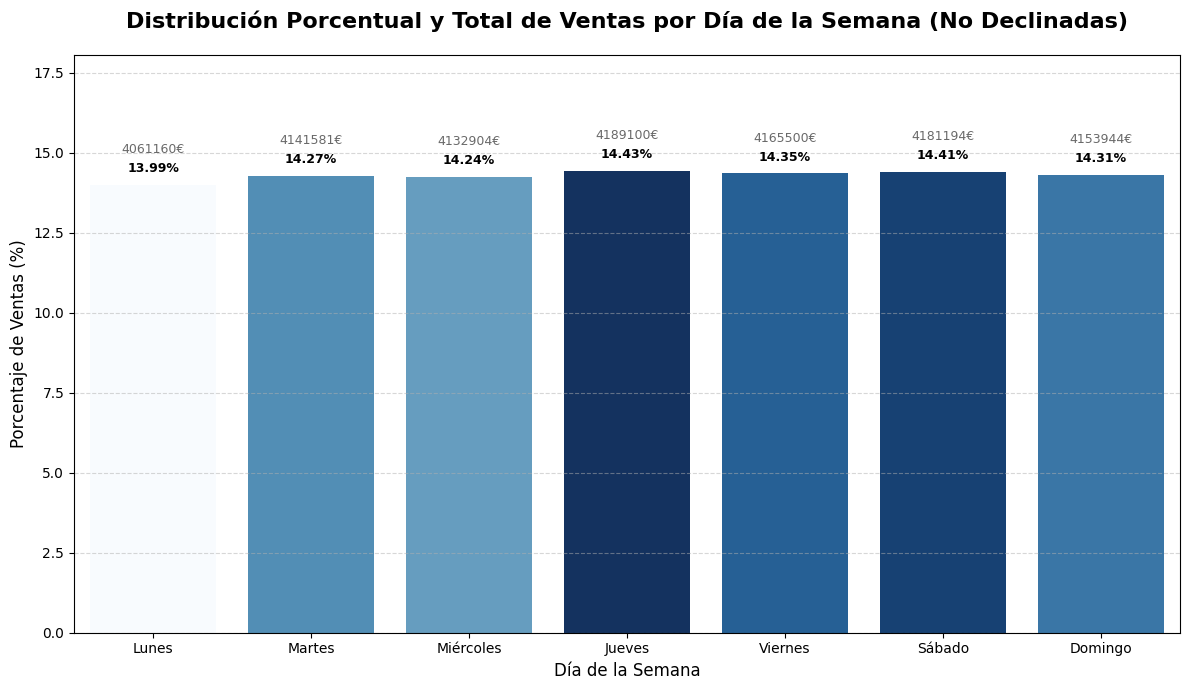

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported
import numpy as np # Ensure numpy is imported

# Define the correct chronological order for days of the week
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df_non_declined = df_transactions[df_transactions['declined'] == 0]

# Calculate total sales amount by day of the week for non-declined transactions
sales_by_day_non_declined = df_non_declined.groupby('dia_semana')['amount'].sum().reset_index()
sales_by_day_non_declined.columns = ['dia_semana', 'total_sales']

# Calculate percentage of total sales
total_global_sales_non_declined = sales_by_day_non_declined['total_sales'].sum()
sales_by_day_non_declined['percentage'] = (sales_by_day_non_declined['total_sales'] / total_global_sales_non_declined) * 100

# Order by percentage (descending)
sales_by_day_non_declined = sales_by_day_non_declined.sort_values(by='percentage', ascending=False)

# Ensure 'dia_semana' is a categorical type with the specified order
sales_by_day_non_declined['dia_semana'] = pd.Categorical(
    sales_by_day_non_declined['dia_semana'],
    categories=orden_dias,
    ordered=True
)

# Sort the DataFrame by the ordered 'dia_semana' for chronological display on x-axis
sales_by_day_non_declined_ordered = sales_by_day_non_declined.sort_values('dia_semana').reset_index(drop=True)

plt.figure(figsize=(12, 7)) # Increased figure size for better readability of two labels

# Normalize percentages to a 0-1 range for the colormap to create the heatmap effect
norm = plt.Normalize(sales_by_day_non_declined_ordered['percentage'].min(), sales_by_day_non_declined_ordered['percentage'].max())
cmap = plt.cm.Blues # Using a blue colormap for heatmap effect
colors = [cmap(norm(p)) for p in sales_by_day_non_declined_ordered['percentage']]

sns.barplot(
    data=sales_by_day_non_declined_ordered,
    x='dia_semana',
    y='percentage',
    hue='dia_semana', # Explicitly assign hue to satisfy the FutureWarning
    palette=colors, # Apply custom colors based on percentage for heatmap effect
    legend=False,
)

plt.title(
    'Distribución Porcentual y Total de Ventas por Día de la Semana (No Declinadas)',
    fontsize=16, pad=20, fontweight='bold'
)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Porcentaje de Ventas (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage and total sales labels on top of the bars, with an offset to prevent overlap
for i, row in sales_by_day_non_declined_ordered.iterrows():
    # Percentage label slightly above the bar
    plt.text(i, row['percentage'] + 0.3, f'{row['percentage']:.2f}%',
             color='black', ha="center", va="bottom", fontsize=9, fontweight='bold')
    # Total sales label a bit higher
    plt.text(i, row['percentage'] + 0.9, f'{row['total_sales']:.0f}€', # Added 0.9 offset
             color='dimgray', ha="center", va="bottom", fontsize=9)

# Adjust y-limit to ensure labels are visible and don't get cut off
plt.ylim(0, sales_by_day_non_declined_ordered['percentage'].max() * 1.25)
plt.tight_layout()
plt.show()

#### Propuesta de Visualización Alternativa (IA de Colab)

Plantea un gráfico de barras verticales enfocado en el porcentaje de ventas (*%*) por día de la semana, filtrando solo las operaciones no rechazadas e incluyendo etiquetas dobles en cada barra (*importe total en euros y porcentaje del total*).

---

### Comparación y Valoración Crítica

* **Propuesta de la IA:** Gráfico de barras porcentuales con etiquetas dobles (*€ y %*) filtrando por ventas aceptadas.
* **Valoración:** **Mejora bastante respecto a la versión base.**

---

### Razones de la Valoración

* **Etiquetado directo (*Data Labels*):** Es el punto fuerte. Incluir encima de cada barra el volumen absoluto (*4.189.100 €*) y el peso relativo (*14,43%*) ahorra tener que andar mirando al eje para calcular a ojo los valores.

* **Foco en el negocio:** Al aclarar en el título que se centra en ventas "No Declinadas", el análisis gana precisión al evaluar únicamente el dinero que realmente ha ingresado.

* **Eje Y en porcentaje:** Ajustar la escala del eje Y entre 0% y 17,5% ayuda a ver mejor las pequeñas diferencias entre días (*donde el lunes se queda en el mínimo con un 13,99% y el jueves alcanza el máximo con un 14,43%*).

## Exercici 2: Preguntes analítiques complexes (amb guia)
🌍 Context: Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

Preguntes analítiques (amb guia general)


### 2.1 Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.

#### Descripción de los Pasos Seguidos

 **Combinación de datos (`pd.merge`)**
   * Se realiza un **LEFT JOIN** entre `df_transactions` y `df_companies` haciendo corresponder `business_id` en las transacciones con `company_id` en las empresas.

 **Agrupación y agregación (`groupby`)**
   * Se agrupa la información resultante por el país de origen de la compañía vendedora (`country`) y se calcula la suma total del importe de facturación (`amount`).

 **Ordenación explícita (`sort_values`)**
   * Se ordenaron los países de mayor a menor volumen de facturación.

 **Cálculo acumulado**
   * Se calcula el porcentaje de participación relativo de cada país sobre el total global y, a partir de este, la curva del porcentaje acumulado.

 **Representación visual**
   * Se construye un gráfico de Pareto combinando barras (*facturación absoluta por país*) y una línea en eje secundario (*porcentaje acumulado*).

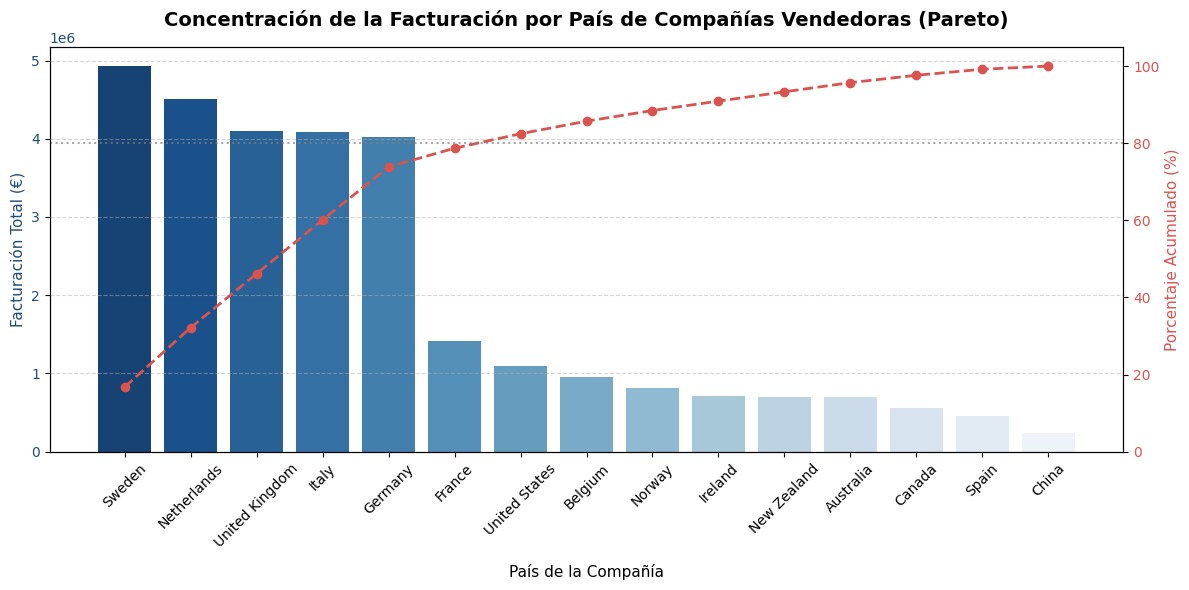

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Unir la tabla de transacciones con la de compañías mediante business_id y company_id
df_merged = pd.merge(
    df_transactions,
    df_companies,
    left_on='business_id',
    right_on='company_id',
    how='left',
)

# Agrupar la facturación total por país de la compañía
facturacion_pais = (
    df_merged.groupby('country')['amount'].sum().reset_index()
)

# Ordenar los países de mayor a menor facturación
facturacion_pais = facturacion_pais.sort_values(
    by='amount', ascending=False
).reset_index(drop=True)

# Calcular el porcentaje relativo y el porcentaje acumulado
facturacion_pais['porcentaje'] = (
    facturacion_pais['amount'] / facturacion_pais['amount'].sum()
) * 100
facturacion_pais['porcentaje_acumulado'] = facturacion_pais[
    'porcentaje'
].cumsum()

# Representación mediante Diagrama de Pareto
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje principal (Eje Y1): Barras de facturación por país
sns.barplot(
    data=facturacion_pais,
    x='country',
    y='amount',
    ax=ax1,
    hue='country',
    palette='Blues_r',
    legend=False,
)

ax1.set_title(
    'Concentración de la Facturación por País de Compañías Vendedoras (Pareto)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
ax1.set_xlabel('País de la Compañía', fontsize=11, labelpad=10)
ax1.set_ylabel('Facturación Total (€)', fontsize=11, color='#1f4e78')
ax1.tick_params(axis='y', labelcolor='#1f4e78')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Eje secundario (Eje Y2): Línea de porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(
    facturacion_pais['country'],
    facturacion_pais['porcentaje_acumulado'],
    color='#d9534f',
    marker='o',
    linewidth=2,
    linestyle='--',
)
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=11, color='#d9534f')
ax2.tick_params(axis='y', labelcolor='#d9534f')
ax2.set_ylim(0, 105)

# Línea de referencia al 80% (Principio de Pareto)
ax2.axhline(80, color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

#### Interpretación y Análisis del Gráfico

---

### Análisis de Resultados

* **El negocio se concentra en Europa:**
  * Los primeros 5 países del gráfico son todos europeos (**Sweden**, **Netherlands**, **United Kingdom**, **Italy** y **Germany**).
  * **Suecia** lidera las ventas rozando los **5 millones de euros**, seguida muy de cerca por Países Bajos y Reino Unido.

* **Se cumple la Regla de Pareto (80/20):**
  * La línea roja de porcentaje acumulado llega casi al **80% de la facturación** al alcanzar el 6º país (**France**).
  * **En resumen:** Solo 6 países (*de los 15 analizables*) generan la inmensa mayoría de los ingresos totales de la plataforma.

* **Caída pronunciada y mercados secundarios:**
  * A partir del grupo de cabeza, el volumen de ventas cae en picado.
  * Mercados potencialmente enormes como **Estados Unidos** (*alrededor de 1,1M €*) o **España** y **China** (*por debajo de los 0,5M €*) se quedan en cifras residuales comparadas con el núcleo europeo.

---

### Implicaciones de Negocio y Recomendaciones

* **Dependencia de un solo mercado:**
  * **Diagnóstico:** Depender tanto de Europa del Norte y Central supone un riesgo claro si cambian las normativas o empeora la economía en esa zona.
  * **Recomendación:** Conviene monitorizar de cerca el contexto macroeconómico y legal de los 6 países principales para reaccionar a tiempo ante cualquier contratiempo.

* **Potencial sin aprovechar en otros países:**
  * **Diagnóstico:** Las bajas cifras en EE. UU. o China indican que falta penetración comercial o que la oferta actual no encaja del todo con el público local.
  * **Recomendación:** Analizar si vale la pena adaptar el modelo (*métodos de pago locales, campañas específicas o traducción de la plataforma*) para arañar cuota en esos mercados.

* **Riesgo Geopolítico y Regulatorio:**
  * Concentrar tanto las ventas expone al negocio a cambios fiscales, variaciones de divisas o problemas de pasarelas de pago en unos pocos países clave.

* **Estrategia Comercial a Futuro:**
  * Hay un margen enorme para crecer fuera del Top 6. El equipo de expansión debería plantearse incentivar la captación en otros países para no jugárselo todo a una sola carta.

### 2.2 Existeix estacionalitat en les vendes?

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.


#### Descripción de los Pasos Seguidos

 **Conversión y extracción temporal:**
   * Se transforma la columna `timestamp` de `df_transactions` al formato `datetime` de Pandas y se extrae el año (`year`) y el mes (`month`).

 **Agregación de datos:**
   * Se calcula la suma total del importe de ventas (`amount`) agrupando por año y mes.

 **Estructuración en Tabla Pivote:**
   * Se crea una `pivot_table` colocando los meses en las filas (del 1 al 12) y los años en las columnas para permitir una comparación directa año a año.

 **Visualización comparativa:**
   * Se representa el comportamiento mensual mediante un gráfico de líneas multiseries donde cada línea representa la evolución de las ventas a lo largo de los meses para un año específico.  
   * Se añade línea de la media en negro

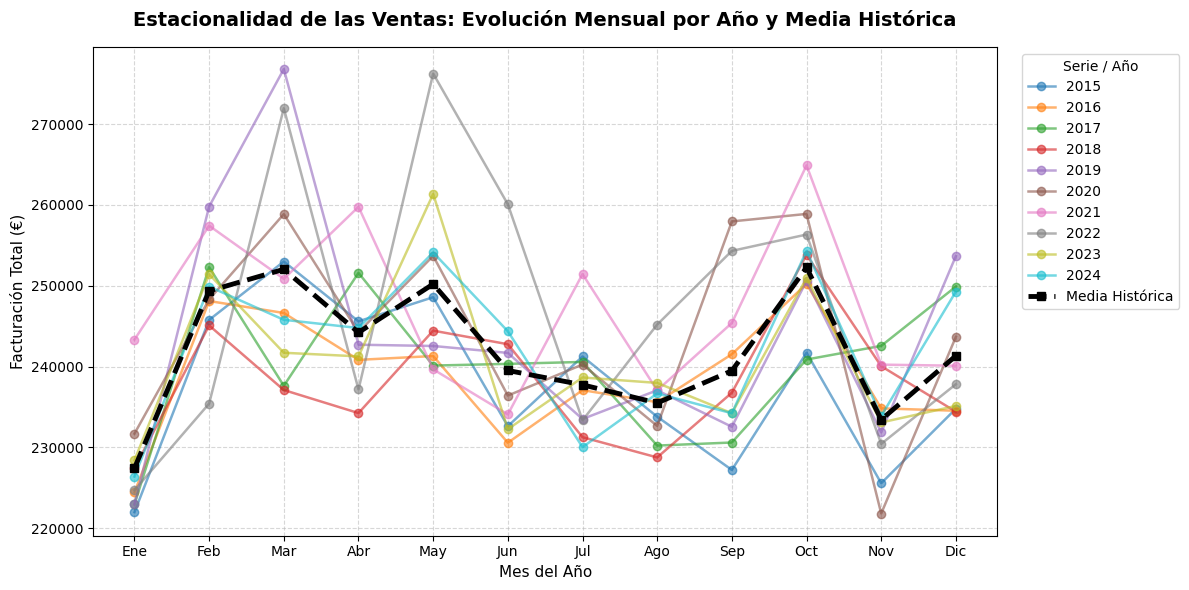

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filtrar ventas válidas y evitar warnings con .copy()
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Asegurar formato datetime y extraer Año y Mes
df_valid['timestamp'] = pd.to_datetime(df_valid['timestamp'])
df_valid['year'] = df_valid['timestamp'].dt.year
df_valid['month'] = df_valid['timestamp'].dt.month

# Crear la Tabla Pivote (Filas: Meses, Columnas: Años, Valores: Suma de Facturación)
pivot_ventas = df_valid.pivot_table(
    index='month', columns='year', values='amount', aggfunc='sum'
)

# Calcular la media histórica mensual a través de todos los años
pivot_ventas['Media_Historica'] = pivot_ventas.mean(axis=1)

# Nombres de los meses para el eje X
meses_es = [
    'Ene',
    'Feb',
    'Mar',
    'Abr',
    'May',
    'Jun',
    'Jul',
    'Ago',
    'Sep',
    'Oct',
    'Nov',
    'Dic',
]

# Visualización a partir de la pivot table
plt.figure(figsize=(12, 6))

# Graficar los años individuales desde la pivot_table
for year in pivot_ventas.columns:
  if year != 'Media_Historica':
    plt.plot(
        pivot_ventas.index,
        pivot_ventas[year],
        marker='o',
        linewidth=1.8,
        alpha=0.6,
        label=str(year),
    )

# Graficar la línea de la media destacada
plt.plot(
    pivot_ventas.index,
    pivot_ventas['Media_Historica'],
    color='black',
    linestyle='--',
    linewidth=3.5,
    marker='s',
    label='Media Histórica',
)

plt.title(
    'Estacionalidad de las Ventas: Evolución Mensual por Año y Media'
    ' Histórica',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Mes del Año', fontsize=11)
plt.ylabel('Facturación Total (€)', fontsize=11)
plt.xticks(ticks=range(1, 13), labels=meses_es)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(
    title='Serie / Año', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True
)

plt.tight_layout()
plt.show()

#### Interpretación del Resultado e Implicaciones para el Negocio

---

###  Análisis de Patrones y Estacionalidad

* **Arranque de año con rebote temprano (Febrero - Marzo):**
  * Casi todos los años empiezan con un suelo bastante marcado en **Enero** (*los mínimos del año, entre 225.000 € y 235.000 €*), para rebotar con fuerza entre **Febrero y Marzo**.
  * En años como **2019 y 2022**, Marzo marcó máximos históricos rozando los **280.000 €**.

* **Primavera bastante irregular (Abril - Mayo):**
  * El comportamiento en primavera varía bastante según el año.
  * Mientras que en **2022 y 2023** hubo picos brutales en **Mayo** (*rozando los 280.000 € y 265.000 €*), en **2019 o 2021** los picos se adelantaron a **Abril** o cayeron más abajo.

* **Parón veraniego (Junio - Agosto):**
  * En los meses de verano las ventas se estabilizan o bajan a un rango medio-bajo (*entre 230.000 € y 245.000 €*), marcando un frenazo estacional bastante constante año tras año.

* **Comportamiento raro a final de año (Octubre vs. Noviembre/Diciembre):**
  * Hay un repunte claro en **Octubre** (*con un pico brutal en 2021 de casi 270.000 €*).
  * Sorprende mucho la caída en picado de **Noviembre** en casi todas las series (*tocando fondo entre 225.000 € y 235.000 €*), para luego remontar un poco en **Diciembre**.

---

### Tendencia General (Año a Año)

* **Sin un patrón estacional fijo:** A diferencia del e-commerce típico donde el último trimestre (con Black Friday y Navidad) arrasa, aquí la estacionalidad cambia mucho. Los picos del año se van moviendo entre Marzo, Mayo y Octubre según el ejercicio.

* **Negocio estancado o en fase madura:** Las líneas de los 10 años (*2015 a 2024*) están apelotonadas en la misma franja (*entre 225.000 € y 280.000 € al mes*). No hay un crecimiento claro año a año; el volumen de ventas está muy plano a largo plazo.

---

### Implicaciones para el Negocio y Recomendaciones

* **Campaña de Black Friday / Navidad desaprovechada:**
  * **Diagnóstico:** El bache de Noviembre indica que no se está sacando partido a campañas potentes como el Black Friday, o que el tipo de producto/vendedor no encaja con esa dinámica.
  * **Recomendación:** Revisar la estrategia del último trimestre y lanzar promociones específicas para reactivar las ventas en Noviembre.

* **Gestión de la liquidez:**
  * **Diagnóstico:** Entre los vaivenes de primavera y los bajones de Enero y Noviembre, los ingresos varían bastante de un mes a otro.
  * **Recomendación:** Guardar colchón de liquidez para los meses flojos y no hacer previsiones de gasto basadas únicamente en los meses pico.

* **Aprender de los mejores meses:**
  * **Diagnóstico:** Hubo picos muy buenos en meses concretos que luego no se repitieron con la misma fuerza.
  * **Recomendación:** Analizar qué se hizo bien en los picos de Marzo (*2019/2022*) u Octubre (*2021*) para ver si se pueden replicar esas acciones el resto del año.

### 2.3 Anàlisi de concentració i variabilitat (tria UNA opció)

#### 2.3.A Opció A - Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.


##### Escogemos la opción A

* **Combinación de transactions con products:**
  * Importamos la tabla de `products` en SQL (fuera de Colab) y pasamos la lista de ids de producto de la tabla `transactions` en el dataframe a una lista como tal de los productos de cada transacción, para un mejor manejo y facilitar cálculos.

#### Descripción de los pasos seguidos
 **Filtrado y desanidado de transacciones:** Se seleccionan las ventas válidas no declinadas (`declined == 0`) y se desanida la lista de identificadores (`product_ids`) mediante `.explode()`.
 **Atribución precisa del precio del catálogo:** Se realiza la unión (*merge*) con `df_products` utilizando la columna **`price`** para calcular los ingresos reales por producto, evitando imputar el valor total de la cesta (`amount`).
 **Cálculo del volumen total e identificación del Top 15:** Se agrupan las ventas por `product_name` calculando la suma total acumulada de ingresos (`facturacion_total`) para extraer los 15 productos líderes.
 **Visualización integrada en dos niveles:**
   * **Panel Superior (Gráfico de Barras):** Muestra el volumen total de ingresos (€) generados por cada uno de los Top 15 productos, incluyendo etiquetas con las cifras exactas.
   * **Panel Inferior (Boxplot):** Muestra la dispersión, mediana y rango intercuartílico de los precios unitarios cobrados en cada transacción directa del producto.


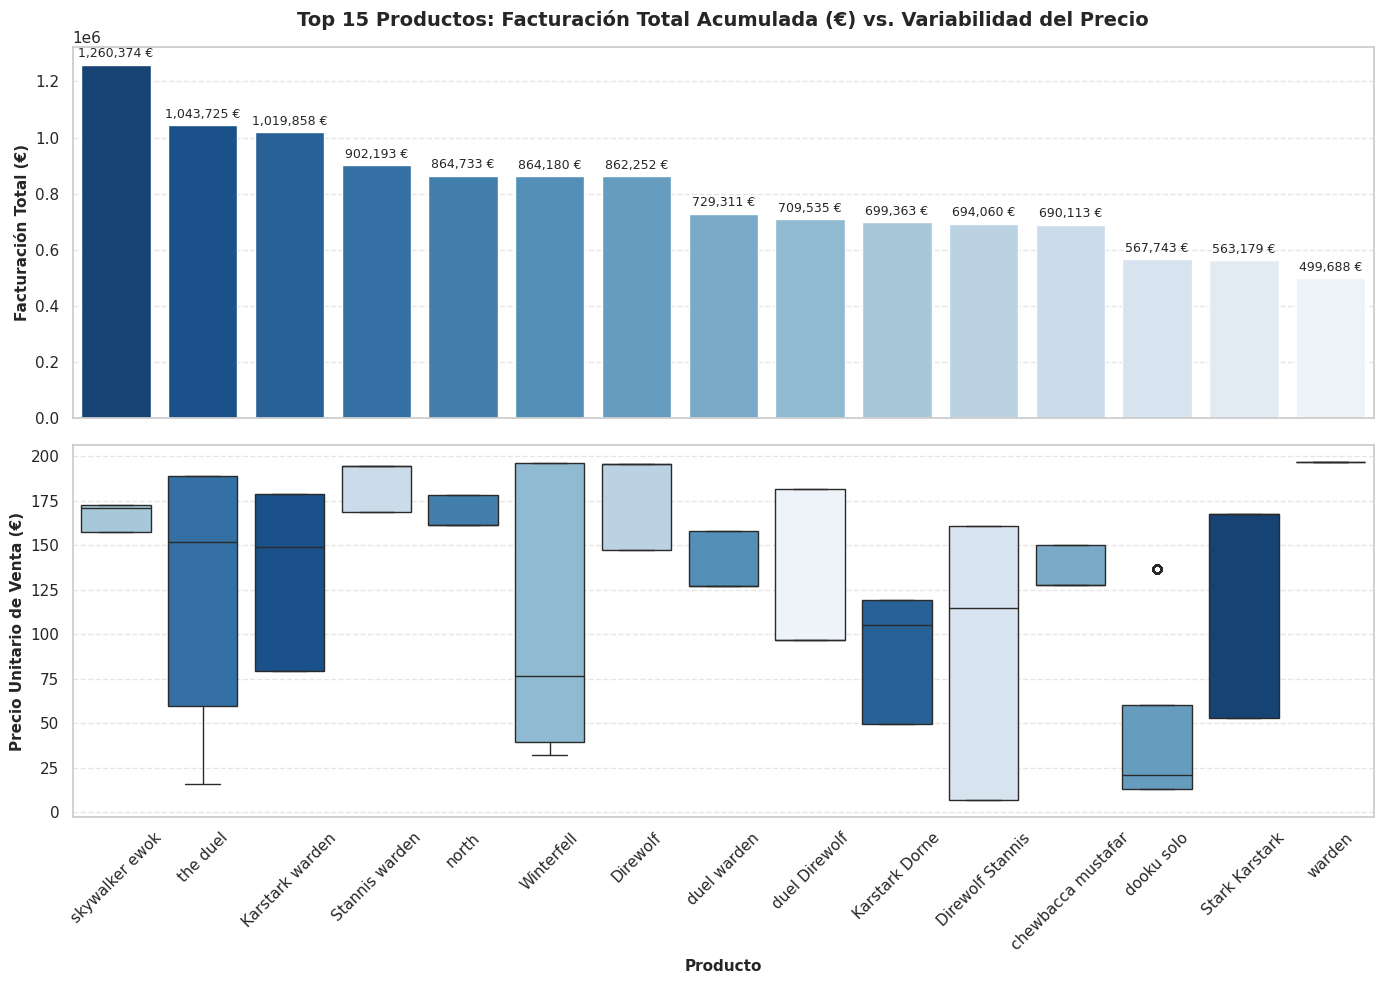

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filtrar transacciones aprobadas
df_trans_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Separar y desanidar la columna product_ids
df_trans_exploded = df_trans_valid.assign(
    product_id=df_trans_valid['product_ids'].astype(str).str.split(',')
).explode('product_id')

# Limpiar espacios y convertir a numérico de forma segura
df_trans_exploded['product_id'] = pd.to_numeric(
    df_trans_exploded['product_id'].astype(str).str.strip(),
    errors='coerce'
)

# Cruce seguro (left join) con el catálogo de productos
df_trans_products = pd.merge(
    df_trans_exploded,
    df_products,
    left_on='product_id',
    right_on='id',
    how='left',
    suffixes=('_tx', '_prod')
)

# Agrupar por producto para obtener la facturación total real y número de ventas
resumen_productos = (
    df_trans_products.groupby('product_name')
    .agg(
        facturacion_total=('price', 'sum'),
        unidades_vendidas=('price', 'count'),
        precio_promedio=('price', 'mean'),
    )
    .reset_index()
)

# Obtener Top 15 productos por Facturación Total
top15_df = resumen_productos.nlargest(15, 'facturacion_total').sort_values(
    'facturacion_total', ascending=False
)
top15_nombres = top15_df['product_name'].tolist()

# Filtrar el dataset desanidado para los productos del Top 15
df_top15_ventas = df_trans_products[
    df_trans_products['product_name'].isin(top15_nombres)
].copy()

# Creacion de la figura compuesta (2 Subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Facturación Total Acumulada (€) por Producto
sns.barplot(
    data=top15_df,
    x='product_name',
    y='facturacion_total',
    ax=ax1,
    palette='Blues_r',
    hue='product_name',
    legend=False,
)
ax1.set_title(
    'Top 15 Productos: Facturación Total Acumulada (€) vs. Variabilidad del'
    ' Precio',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax1.set_ylabel('Facturación Total (€)', fontsize=11, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas con el valor exacto (€) encima de cada barra
for p in ax1.patches:
  height = p.get_height()
  if height > 0:
    ax1.annotate(
        f'{height:,.0f} €',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points',
    )

# Subplot 2: Dispersión y Variabilidad del Precio Unitario por Venta
sns.boxplot(
    data=df_top15_ventas,
    x='product_name',
    y='price',
    order=top15_nombres,
    ax=ax2,
    palette='Blues_r',
    hue='product_name',
    legend=False,
)
ax2.set_ylabel('Precio Unitario de Venta (€)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Producto', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Interpretación e implicaciones para el negocio

* **Visión combinada de Volumen vs. Variabilidad:** La combinación de ambos gráficos resuelve la distorsión del boxplot aislado, permitiendo correlacionar el peso total de facturación de cada producto con la estabilidad o volatilidad de su precio.
* **Identificación de patrones de fijación de precios:**
  * **Productos de precio estable (p. ej., `warden`):** Presentan cajas ultra estrechas en la parte superior del rango de precios, actuando como productos prémium de tarifa fija y alta contribución.
  * **Productos con alta dispersión (p. ej., `Winterfell`, `the duel`):** Muestran cajas amplias que abarcan desde importes reducidos hasta precios máximos, lo que refleja un uso intensivo de promociones, descuentos escalonados o precios dinámicos según el canal o tipo de usuario.
* **Estrategia comercial:** Permite a la dirección de ventas evaluar si los productos con mayor facturación global lo logran mediante un volumen elevado de ventas a precio estable o mediante transacciones de alto valor con márgenes variables.

#### 2.3.B Opció B - Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.


### **2.4 Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

+ Per a cada pregunta:

+ - Descriu breument els passos seguits.

+ - Mostra la visualització final.

+ - Interpreta què implica per al negoci.

#### Descripción de los Pasos Seguidos

 **Segmentación por franjas horarias:**
   * Diseñamos una función para dividir el día en 4 bloques de 6 horas:
     * **Madrugada:** 00:00 a 05:59 h (*de 0 a 5 h*).
     * **Mañana:** 06:00 a 11:59 h (*de 6 a 11 h*).
     * **Tarde:** 12:00 a 17:59 h (*de 12 a 17 h*).
     * **Noche:** 18:00 a 23:59 h (*de 18 a 23 h*).

 **Enriquecimiento del dataset:**
   * Aplicamos la función para asignar la franja horaria correspondiente a cada transacción y creamos una nueva columna en el *DataFrame*.

 **Visualización de patrones:**
   * Generamos un gráfico de calor (*Heatmap*) cruzando las franjas horarias con los años para analizar fácilmente cómo han evolucionado los hábitos de compra a lo largo del tiempo.

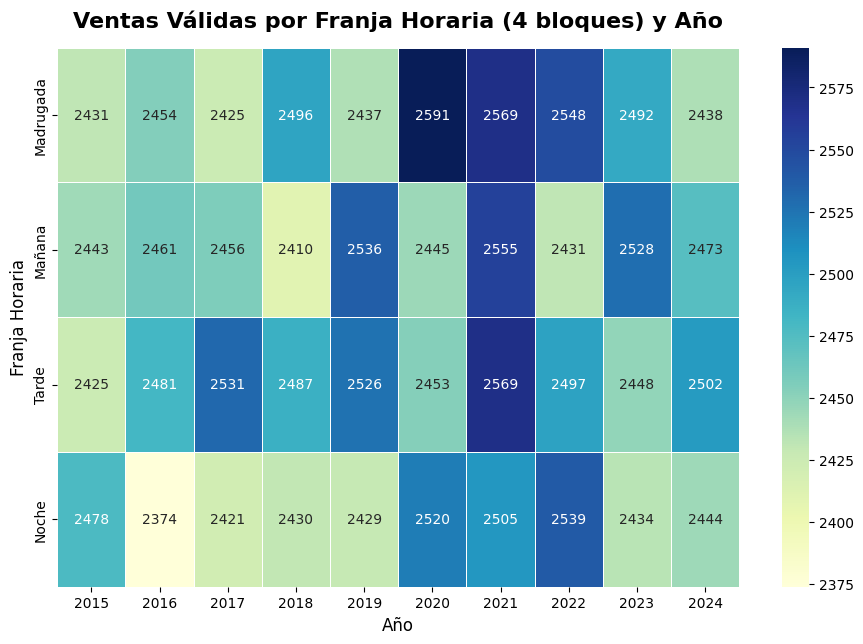

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Definimos la función con 4 franjas horarias (6 horas cada una)
def asignar_franja_horaria_4(hora):
  if 0 <= hora < 6:
    return 'Madrugada'
  elif 6 <= hora < 12:
    return 'Mañana'
  elif 12 <= hora < 18:
    return 'Tarde'
  else:
    return 'Noche'  # De 18:00 a 23:59 h


# Filtramos solo transacciones válidas y creamos una copia limpia
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Extraemos hora y año, y aplicamos la función
df_valid['franja_horaria'] = df_valid['timestamp'].dt.hour.apply(
    asignar_franja_horaria_4
)
df_valid['year'] = df_valid['timestamp'].dt.year

# Construimos la tabla agregada cruzando franja_horaria y año
tabla_agregada = pd.crosstab(df_valid['franja_horaria'], df_valid['year'])

# Reordenar las filas para que aparezcan en orden cronológico natural
orden_franjas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
tabla_agregada = tabla_agregada.reindex(orden_franjas)

# Visualización Heatmap
plt.figure(figsize=(11, 7))
sns.heatmap(tabla_agregada, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title(
    'Ventas Válidas por Franja Horaria (4 bloques) y Año',
    fontsize=16,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Franja Horaria', fontsize=12)
plt.show()

#### Interpretación e implicaciones para el negocio

* **Distribución uniforme y estabilidad operativa:** A diferencia de otros patrones comerciales con picos muy pronunciados en horas centrales, la matriz refleja un volumen de ventas notablemente homogénico entre las distintas franjas horarias y a lo largo del periodo analizado (manteniéndose de manera estable entre las ~2.370 y ~2.590 transacciones por bloque).
* **Análisis de la demanda nocturna e internacional:** El elevado volumen registrado en la franja de *Madrugada* (con picos máximos en los años 2020 a 2022 que superan las 2.560 ventas) pone de manifiesto una actividad ininterrumpida de la plataforma (24/7). Esto sugiere la presencia de un perfil de usuario global situado en diferentes zonas horarias o un comportamiento de compra digital automatizado.
* **Evolución interanual y picos de actividad:** El periodo comprendido entre 2020 y 2022 registra la mayor intensidad de operaciones de la serie temporal en casi todas las franjas, coincidiendo con la Pandemia de COVID-19. A partir de 2023 se observa una moderación y estabilización del volumen de operaciones en valores cercanos a la media histórica.
* **Recomendaciones estratégicas:**
  * **Mantenimiento y soporte técnico:** Las tareas de mantenimiento informático, despliegues en producción o actualizaciones de servidor no deben programarse de forma agresiva durante la madrugada, ya que existe un nivel de facturación real que podría verse impactado.
  * **Dimensión de infraestructura e IA:** Se recomienda mantener sistemas de escalado automático (*auto-scaling*) en la plataforma y disponer de soporte al cliente o asistentes virtuales automatizados de forma ininterrumpida durante las 24 horas del día.

# Nivell 2 - Anàlisi relacional i patrons avançats

## Exercici 1: Anàlisi de productes i captació d'usuaris


🎯 Objectiu: Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.

Els productes que generen més ingressos també impulsen el creixement del negoci mitjançant la captació de nous usuaris, o bé el negoci depèn principalment d'usuaris recurrents comprant els mateixos productes?

Passos orientatius:

1. Combina les taules necessàries.

2. Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.

3. Agrega la informació per producte i calcula les mètriques següents:

- Ingressos totals.
- Variabilitat dels ingressos.
- Nombre de nous usuaris.
- Percentatge de nous usuaris sobre el total de compradors del producte.

4. Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:

- Captador: alta captació de nous usuaris.
- Recurrent: ingressos elevats però baixa captació.
- Emergent: baixa facturació però bona captació.
- Estancat: baixos ingressos i baixa captació.

5. Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:

- Eix X → ingressos totals per producte.
- Eix Y → nombre de nous usuaris.
- Mida del punt → variabilitat dels ingressos.
- Color del punt → tipologia analítica del producte.
📌 Nota important

No es tracta només de mostrar gràfics, sinó d'interpretar què implica per al negoci no captar nous usuaris.



#####  Pasos seguidos
 **Definición de nuevo usuario:** Se determina la fecha de la primera transacción histórica registrada en el sistema para cada `user_id`. Se asigna la marca `es_nuevo_usuario = True` únicamente a las transacciones cuya fecha coincide con dicha primera compra.
 **Desglose de productos:** Se desglosa la columna `product_ids` mediante la función `explode()` y se combina el resultado con el catálogo (`df_products`) para imputar los ingresos según el precio unitario del producto (`price`).
 **Cálculo de métricas agregadas:** Por cada producto se calcula:
   * **Ingresos totales:** Sumatorio del precio unitario de sus ventas.
   * **Variabilidad de ingresos:** Desviación estándar de los precios cobrados por el producto.
   * **Volumen de captación:** Total de nuevos usuarios que compraron el producto en su primera transacción.
   * **Porcentaje de captación:** Proporción de nuevos usuarios frente al total de compradores del artículo.
 **Segmentación estratégica de catálogo:** Se clasifican los artículos en cuatro tipologías en función de si superan la mediana global de ingresos y captación:
   * **Captador:** Ingresos elevados y alta captación de nuevos usuarios.
   * **Recurrent:** Ingresos elevados pero baja captación (dependencia de clientes habituales).
   * **Emergent:** Bajos ingresos pero buena captación de nuevos usuarios.
   * **Estancat:** Bajos ingresos y baja capacidad de atracción de clientes.
 **Visualización multidimensional:** Se construye un gráfico de dispersión (*scatter plot*) representando simultáneamente ingresos (Eje X), captación (Eje Y), variabilidad del precio (tamaño de la burbuja) y tipología del producto (color).

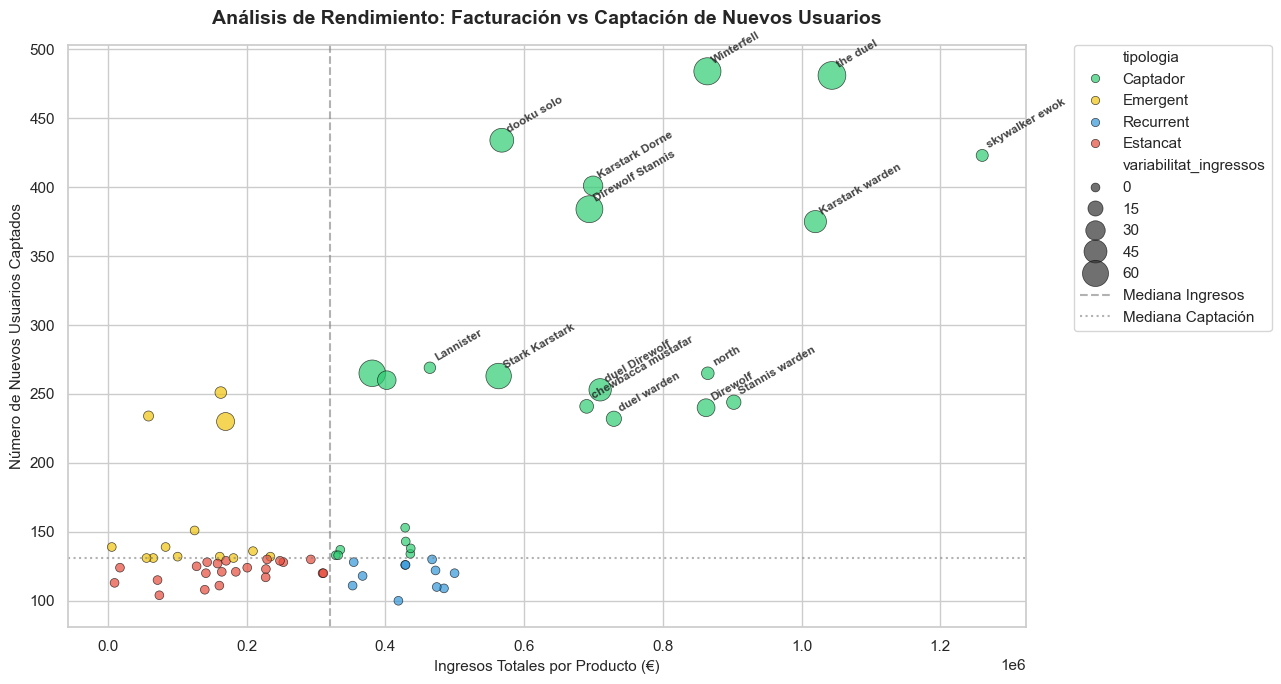

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Preparación de datos y definición de 'Nuevo Usuario'
# Filtrar transacciones válidas (no declinadas)
df_valid_tx = df_transactions[df_transactions['declined'] == 0].copy()
df_valid_tx['timestamp'] = pd.to_datetime(df_valid_tx['timestamp'])

# Identificar la fecha de la primera transacción histórica de cada usuario
primera_tx_usuario = df_valid_tx.groupby('user_id')['timestamp'].min().reset_index()
primera_tx_usuario.rename(columns={'timestamp': 'fecha_primera_tx'}, inplace=True)

# Cruzar para marcar si la transacción es la primera del usuario en el sistema
df_valid_tx = df_valid_tx.merge(primera_tx_usuario, on='user_id', how='left')
df_valid_tx['es_nuevo_usuario'] = df_valid_tx['timestamp'] == df_valid_tx['fecha_primera_tx']

# Desglose de productos (explode) y merge con catálogo
# Desanidar la columna product_ids
if df_valid_tx['product_ids'].dtype == 'object' and isinstance(df_valid_tx['product_ids'].iloc[0], str):
    df_valid_tx['product_id'] = df_valid_tx['product_ids'].str.split(',')
else:
    df_valid_tx['product_id'] = df_valid_tx['product_ids']

df_exploded = df_valid_tx.explode('product_id')
df_exploded['product_id'] = df_exploded['product_id'].astype(int)

# Cruce con el catálogo de productos para obtener el precio unitario y el nombre
df_merged = df_exploded.merge(
    df_products,
    left_on='product_id',
    right_on='id',
    suffixes=('_tx', '_prod')
)

# Agregación de métricas por Nombre de producto
# Agrupamos por 'product_name' para consolidar todos los IDs que comparten el mismo nombre
prod_metrics = df_merged.groupby('product_name').agg(
    ingressos_totals=('price', 'sum'),
    variabilitat_ingressos=('price', 'std'),
    nous_usuaris=('es_nuevo_usuario', lambda x: x.sum()),
    total_compradors=('user_id', 'nunique')
).reset_index()

# Rellenar variabilidad nula con 0
prod_metrics['variabilitat_ingressos'] = prod_metrics['variabilitat_ingressos'].fillna(0)
prod_metrics['pct_nous_usuaris'] = (prod_metrics['nous_usuaris'] / prod_metrics['total_compradors']) * 100

# Creación de la Tipología Analítica de Productos
# Usamos las medianas de ingresos y captación como umbrales objetivos de segmentación
mediana_ingressos = prod_metrics['ingressos_totals'].median()
mediana_captacio = prod_metrics['nous_usuaris'].median()

def clasificar_producto(row):
    if row['ingressos_totals'] >= mediana_ingressos and row['nous_usuaris'] >= mediana_captacio:
        return 'Captador'
    elif row['ingressos_totals'] >= mediana_ingressos and row['nous_usuaris'] < mediana_captacio:
        return 'Recurrent'
    elif row['ingressos_totals'] < mediana_ingressos and row['nous_usuaris'] >= mediana_captacio:
        return 'Emergent'
    else:
        return 'Estancat'

prod_metrics['tipologia'] = prod_metrics.apply(clasificar_producto, axis=1)

# Visualización: Scatter Plot Multidimensional
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# Paleta de colores para las 4 tipologías
paleta_tipologia = {
    'Captador': '#2ecc71',   # Verde
    'Recurrent': '#3498db',  # Azul
    'Emergent': '#f1c40f',   # Amarillo / Naranja
    'Estancat': '#e74c3c'    # Rojo
}

scatter = sns.scatterplot(
    data=prod_metrics,
    x='ingressos_totals',
    y='nous_usuaris',
    size='variabilitat_ingressos',
    hue='tipologia',
    palette=paleta_tipologia,
    sizes=(40, 400),
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Seleccionamos qué productos destacar, añadiendo su nombre, para evitar la saturación visual
productos_a_destacar = prod_metrics[
    (prod_metrics['tipologia'] == 'Captador') |
    (prod_metrics['ingressos_totals'] >= prod_metrics['ingressos_totals'].quantile(0.85))
].sort_values(by='ingressos_totals', ascending=False).head(15)

for i, row in productos_a_destacar.iterrows():
    plt.annotate(
        row['product_name'],
        (row['ingressos_totals'], row['nous_usuaris']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8.5,
        rotation=30,             # Rotación en grados para legibilidad
        rotation_mode='anchor',
        fontweight='bold' if row['tipologia'] == 'Captador' else 'normal',
        alpha=0.85
    )

# Líneas de referencia según las medianas de segmentación
plt.axvline(mediana_ingressos, color='gray', linestyle='--', alpha=0.6, label='Mediana Ingresos')
plt.axhline(mediana_captacio, color='gray', linestyle=':', alpha=0.6, label='Mediana Captación')

plt.title("Análisis de Rendimiento: Facturación vs Captación de Nuevos Usuarios", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ingresos Totales por Producto (€)", fontsize=11)
plt.ylabel("Número de Nuevos Usuarios Captados", fontsize=11)

# Ajuste de la leyenda fuera del área del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

##### Análisis del gráfico y dinámica del catálogo

El gráfico de dispersión evidencia una fuerte dependencia estratégica del catálogo respecto a un grupo reducido de productos líderes. Las líneas de corte definidas por las medianas permiten extraer las siguientes conclusiones clave sobre la estructura actual del negocio:

 **Concentración de la atracción en productos *Captadores* (Verdes):**
   Un grupo concreto de artículos (como `Winterfell`, `the duel` o `dooku solo`) lidera simultáneamente la facturación total (superando los 500.000 € e incluso alcanzando 1,2 M€) y la captación de clientes (entre 250 y 500 nuevos usuarios).
   
* **Tamaño del punto (Variabilidad del registro):**
  En coherencia con los análisis anteriores (donde se demostró que el precio unitario de catálogo es fijo y rígido), el mayor tamaño del punto en los productos *Captadores* no responde a fluctuaciones de precio ni a descuentos promocionales. En su lugar, refleja una mayor dispersión muestral inherente al elevado volumen de transacciones en las que participan estos artículos principales.

 **Estabilidad del bloque de *Recurrentes* (Azules):**
   Los productos clasificados como *Recurrentes* generan ingresos consolidados (entre 300.000 € y 500.000 €), pero su volumen de captación se mantiene bajo (entre 100 y 140 nuevos usuarios). Estos artículos sostienen el volumen de facturación a través de la repetición de compra de clientes existentes, actuando como base de ingresos estables.

 **Riesgo por volumen de productos *Estancados* (Rojos) y *Emergentes* (Amarillos):**
   Existe una concentración significativa de productos situados por debajo del umbral de captación. En particular, los productos *Estancados* representan un coste de oportunidad, ya que consumen recursos de gestión sin aportar tracción en volumen de ventas ni en captación de nuevos clientes.

---

#### ¿Qué implica para el negocio no captar nuevos usuarios?

La captación de nuevos clientes es el motor de sostenibilidad a largo plazo de cualquier modelo comercial. La falta de adquisición o una dependencia excesiva de productos recurrentes conlleva los siguientes **riesgos críticos para la empresa**:

* **Erosión progresiva de la base de clientes:** Todos los negocios sufren una tasa natural de abandono de usuarios. Si los productos no atraen nuevos compradores para compensar estas bajas, la base activa de clientes decrecerá a medio y largo plazo.
* **Estancamiento del techo de ingresos:** Confiar únicamente en usuarios recurrentes limita la facturación al consumo máximo que estos puedan realizar. Sin la entrada de nuevos usuarios, el crecimiento global de la empresa se paraliza.
* **Vulnerabilidad y concentración del riesgo:** Si la adquisición depende de un número tan reducido de productos *Captadores*, cualquier cambio en la tendencia del mercado, ruptura de stock o incremento en los costes de adquisición sobre estos artículos específicos pondría en peligro la entrada total de nuevos clientes al sistema.

---

#### Recomendaciones para la empresa

 **Protección y potenciación de productos *Captadores*:**
   Garantizar la disponibilidad continua de stock y destinar la mayor parte del presupuesto de marketing digital a los productos estrella (`Winterfell`, `the duel`, `dooku solo`), asegurando que sigan funcionando como la puerta de entrada principal al catálogo.

 **Estrategia de conversión sobre productos *Emergentes*:**
   Analizar el perfil de los usuarios atraídos por los productos amarillos (alta captación pero bajos ingresos) e implementar estrategias de *cross-selling* (venta cruzada) o *upselling* (ofrecer versiones superiores) para elevar el valor medio de su primera compra.

 **Planes de fidelización para productos *Recurrentes*:**
   Diseñar programas de suscripción o incentivos de recompra sobre los productos azules para asegurar que la tasa de retención de los usuarios actuales se mantenga elevada sin necesidad de realizar grandes esfuerzos comerciales de captación sobre ellos.

 **Auditoría y optimización del catálogo *Estancado*:**
   Revisar los artículos ubicados en el cuadrante rojo. Aquellos que no aporten margen suficiente ni atracción deben ser liquidados o descatalogados para liberar capital y recursos logísticos en favor de los productos con mayor tracción.

## Exercici 2: Anàlisi geogràfica company–usuari i oportunitats d'expansió
🎯 Objectiu: Analitzar la relació entre el país de les companyies venedores, el país de residència dels usuaris i el flux de compra entre països.

El negoci està basat en mercats locals (mateix país usuari–companyia) o hi ha una oportunitat real d'expansió internacional obrint més companyies en certs països?

Passos orientatius:

1. Combina les taules necessàries.

2. Crea una variable clau d'anàlisi: compra_local = True/False.

3. Analitza el comportament global:
- Percentatge de transaccions locals vs internacionals.
- Percentatge de facturació local vs internacional.

4. Anàlisi per país de l'usuari, per cada país d'usuari:

- % de compres a companyies del mateix país.
- % de compres a companyies estrangeres.
- Import total comprat.

5. Anàlisi per país de companyia, per cada país de companyia calcula quina part de la seva facturació ve de:

- Usuaris locals.
- Usuaris estrangers.

6. Escull una visualització que expliqui clarament el fenomen.

7. Interpretació estratègica:

- En quins països valdria la pena obrir més companyies locals?
- Hi ha països amb demanda però poca oferta local?
- El negoci depèn massa de companyies d'un sol país?
- Obrir companyies locals reduiria fricció o milloraria conversió?


#### Descripción de los Pasos Seguidos

 **Unión de tablas (`df_transactions`, `df_companies`, `df_users`):**
   * Hicimos un **LEFT JOIN** filtrando solo las transacciones válidas (`declined == 0`), cruzando con `companies` (*para sacar el país de la empresa*) y con `users` (*para sacar el país de residencia del comprador*).

 **Creación de la métrica clave (`compra_local`):**
   * Creamos la variable booleana `compra_local = (pais_usuario == pais_companyia)` para clasificar cada operación como **Local** o **Internacional**.

 **Análisis del comportamiento global:**
   * Calculamos el **% sobre el volumen de transacciones** y el **% sobre la facturación total (€)** para comparar el peso del mercado nacional vs. transfronterizo.

 **Análisis bidireccional por país:**
   * **Desde la perspectiva del Usuario (Demanda):** Miramos el gasto total por país y qué parte se destina a empresas locales frente a extranjeras.
   * **Desde la perspectiva de la Empresa (Oferta):** Analizamos la facturación total captada y la proporción que proviene de clientes locales vs. internacionales.

 **Visualización de la Matriz de Oportunidad de Expansión:**
   * Montamos un gráfico de barras apiladas al 100% ordenado por la demanda total de cada país, lo que permite ver de un vistazo qué países "fugan" más capital hacia empresas de fuera.

              === 1. COMPORTAMIENTO GLOBAL ===


,tipo_compra,transacciones,pct_transacciones,facturacion,pct_facturacion
0,Internacional (Extranjero),87346,88.13%,25574073.22,88.11%
1,Local (Mismo País),11766,11.87%,3451309.19,11.89%


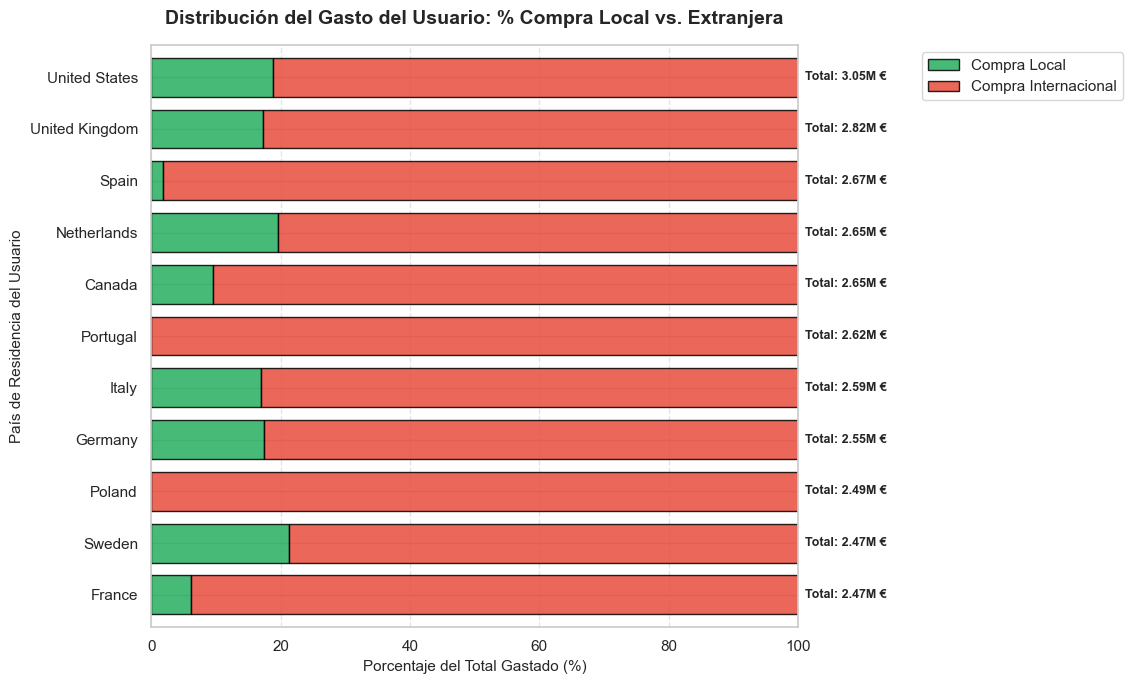

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Filtrar transacciones válidas
df_valid = df_transactions[df_transactions['declined'] == 0].copy()

# Merge de Transacciones con Companies y Users
# Renombramos columnas de país para evitar colisiones
df_geo = pd.merge(
    df_valid,
    df_companies[['company_id', 'country']].rename(
        columns={'country': 'pais_companyia'}
    ),
    left_on='business_id',
    right_on='company_id',
    how='left',
)

df_geo = pd.merge(
    df_geo,
    df_users[['id', 'country']].rename(columns={'country': 'pais_usuario'}),
    left_on='user_id',
    right_on='id',
    how='left',
)

# Variable clave: Compra Local
df_geo['compra_local'] = df_geo['pais_usuario'] == df_geo['pais_companyia']
df_geo['tipo_compra'] = np.where(
    df_geo['compra_local'], 'Local (Mismo País)', 'Internacional (Extranjero)'
)

# Análisis Global
tot_facturacion = df_geo['amount'].sum()
tot_transacciones = len(df_geo)

global_metrics = (
    df_geo.groupby('tipo_compra')
    .agg(
        transacciones=('id_x', 'count'),
        facturacion=('amount', 'sum'),
    )
    .reset_index()
)

global_metrics['pct_transacciones'] = global_metrics['transacciones'].apply(
    lambda x: f"{round((x / tot_transacciones) * 100, 2)}%"
)
global_metrics['pct_facturacion'] = global_metrics['facturacion'].apply(
    lambda x: f"{round((x / tot_facturacion) * 100, 2)}%"
)

print('              === 1. COMPORTAMIENTO GLOBAL ===')
display(
    global_metrics[
        [
            'tipo_compra',
            'transacciones',
            'pct_transacciones',
            'facturacion',
            'pct_facturacion',
        ]
    ]
)

# Análisis por País de Usuario (Demanda)
user_geo = (
    df_geo.groupby(['pais_usuario', 'tipo_compra'])['amount']
    .sum()
    .unstack(fill_value=0)
)
user_geo['Total_Demanda'] = user_geo.sum(axis=1)

# Asegurar columnas
for col in ['Local (Mismo País)', 'Internacional (Extranjero)']:
    if col not in user_geo.columns:
        user_geo[col] = 0

user_geo['Pct_Local'] = (
    user_geo['Local (Mismo País)'] / user_geo['Total_Demanda']
) * 100
user_geo['Pct_Internacional'] = (
    user_geo['Internacional (Extranjero)'] / user_geo['Total_Demanda']
) * 100
user_geo = user_geo.sort_values(by='Total_Demanda', ascending=False)

# Visualización: Fuga de Demanda por País del Usuario
fig, ax = plt.subplots(figsize=(12, 7))

# Gráfico de barras apiladas al 100%
user_geo_pct = user_geo[['Pct_Local', 'Pct_Internacional']]

user_geo_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#27ae60', '#e74c3c'],
    width=0.75,
    edgecolor='black',
    alpha=0.85,
)

plt.title(
    'Distribución del Gasto del Usuario: % Compra Local vs. Extranjera',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Porcentaje del Total Gastado (%)', fontsize=11)
plt.ylabel('País de Residencia del Usuario', fontsize=11)
plt.legend(
    ['Compra Local', 'Compra Internacional'],
    bbox_to_anchor=(1.18, 1),
    loc='upper left',
)
plt.xlim(0, 100)
plt.gca().invert_yaxis()  # El país con más demanda arriba
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Añadir etiquetas con el valor absoluto gastado a la derecha
for i, (index, row) in enumerate(user_geo.iterrows()):
    ax.text(
        101,
        i,
        f"Total: {row['Total_Demanda']/1e6:.2f}M €",
        va='center',
        fontsize=9,
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

#### Interpretación Estratégica y Preguntas de Negocio

---

### Análisis del Comportamiento Global *(Métricas Clave)*

* **El comercio Internacional arrasa (*Cross-border*):**
  * El **88,11% de la facturación global** (*25,57 M€*) y el **88,13% de las transacciones** (*87.346 pedidos*) son ventas internacionales donde la empresa y el comprador están en países distintos.
* **El mercado Local es casi testimonial:**
  * La compra local representa solo el **11,89% de los ingresos** (*3,45 M€*), lo que confirma que la plataforma opera de forma natural como un *marketplace* de comercio internacional.

---

### Respuesta a las Preguntas Clave del Negocio

 **¿El negocio se basa en mercados locales o hay oportunidad real de expansión internacional?**
   * El modelo **no se apoya en mercados locales**; es claramente internacional. Aun así, que el 88% de los compradores tenga que pedir fuera sugiere que hay una **oportunidad enorme para crecer en oferta local**. Al obligar al usuario a comprar a empresas extranjeras, le estamos sumando costes de envío, plazos de entrega más largos y posibles comisiones por cambio de divisa.

 **¿En qué países valdría la pena captar más empresas locales? (Demanda vs. Oferta Local)**  
   * **España** (*2,67 M€ de demanda*) y **Francia** (*2,47 M€*): Sufren una fuga internacional casi total (*alrededor del 95% del gasto de sus usuarios se va a empresas extranjeras*). Captar vendedores locales aquí permitiría retener un gran capital.
   * **Portugal y Polonia (*2,62 M€ y 2,49 M€ de demanda*):** Casos extremos donde la compra local es prácticamente **cero (0%)**. Hay una demanda brutal de más de 2,5 M€ por país que no tiene ninguna opción de compra local dentro de la plataforma.

 **¿Hay países con mucha demanda pero poquísima oferta local?**
   * **Sí, en casi todos.** Salvo ligeros focos de oferta local en *EE. UU.*, *Países Bajos*, *Suecia*, *Alemania*, *Reino Unido* e *Italia* (*donde la compra local apenas llega al 15% - 21%*), mercados como **Portugal, Polonia, España y Francia sufren una falta crítica de oferta local**.

 **¿Dependemos demasiado de las empresas de unos pocos países?**
   * Sí. Como el 88,11% del dinero cruza fronteras mientras que los compradores están repartidos de forma bastante pareja por los 11 países (*todos gastan entre 2,47 M€ y 3,05 M€*), se nota que **los vendedores están muy concentrados en solo 2 o 3 países exportadores**. El negocio depende bastante de lo que pase en esos pocos países de origen.

 **¿Tener compañías locales mejoraría la conversión y reduciría fricciones?**
   * **Sin duda.** Captar vendedores o abrir entidades locales en los países con más "fuga" (*Portugal, Polonia, España, Francia*) daría ventajas clarísimas:
     * **Envíos más rápidos y baratos:** Logística nacional mucho más eficiente.
     * **Cero problemas con divisas o aduanas y aranceles:** Facturación directa en moneda local y normativa conocida.
     * **Mayor tasa de conversión en el *checkout*:** Al usuario siempre le da más confianza comprar en una tienda de su propio país.

# Nivell 3 - Visualització executiva i storytelling


## Exercici 1: Mini-dashboard departamental
🎯 Objectiu: Construeix un mini-dashboard en Python utilitzant Google Colab. Aquest exercici està pensat perquè tot el desenvolupament principal es faci dins del notebook, utilitzant Colab com a eina d'anàlisi i visualització.

L'opció principal i recomanada és la següent.





📌 Condició comuna a TOTES les opcions
Independentment de l'opció triada: el mini-dashboard va orientat a UN dels següents departaments:

» Marketing.

» Vendes / Comercial.

» Producció.

» Sistemes / Ciberseguretat.

Les visualitzacions han de ser:

» Rellevants per al departament escollit.

» Clares i llegibles.

» Coherents entre si.

👉 No es valora la complexitat gràfica, sinó:

» La selecció adequada de mètriques.

» La capacitat de síntesi.

» La coherència del missatge.


### 1. Figura única amb subplots (enfocament analític clàssic)

Construcció d'una única figura amb 4 subplots utilitzant matplotlib i/o seaborn.

Requisits:

- 1 figura
- 4 visualitzacions diferents

Si tens temps i vols aprofundir en una solució una mica més complexa, al final es presenten opcions avançades opcionals:

Google Colab està pensat principalment per a treball analític en notebooks. Per aquest motiu, la construcció de dashboards amb Streamlit o Dash no és recomanada dins de Colab, ja que requereix l'execució d'aplicacions web en un entorn local.

Les opcions de dashboard amb Streamlit o Dash es consideren opcions avançades i opcionals, i només s'han de desenvolupar en entorn local de Python.

#### Pasos Seguidos

 **Selección del departamento:**
   * Nos enfocamos en el área de **Ventas / Comercial**, centrando el análisis en métricas como facturación real, volumen de pedidos, rotación de productos y ventas internacionales.

 **Limpieza y preparación de datos:**
   * **Filtrado inicial:** Nos quedamos solo con las operaciones aprobadas (`declined == 0`).
   * **Desagregación del catálogo:** Desanidamos la columna `product_ids` para analizar el comportamiento producto a producto.
   * **Cruce de tablas:** Unimos los datos con `companies` y `users` para incorporar la parte geográfica (*país de la empresa y del cliente*).

 **Creación de cuadros de mando y visualizaciones:**
   * **Opción estática (Colab Subplots):** Montamos un panel 2x2 integrado usando Matplotlib y Seaborn.
   * **Opción interactiva (Dashboard):** Diseñamos el prototipo de la app interactiva con filtros laterales y KPIs (*inicialmente pensado en Streamlit, pero adaptado a Power BI para poder generar el archivo `.pbix` que pide la entrega*). **Se entrega pdf de la visualización en Streamlit y fichero .pbix de PowerBI en el repositorio GitHub**

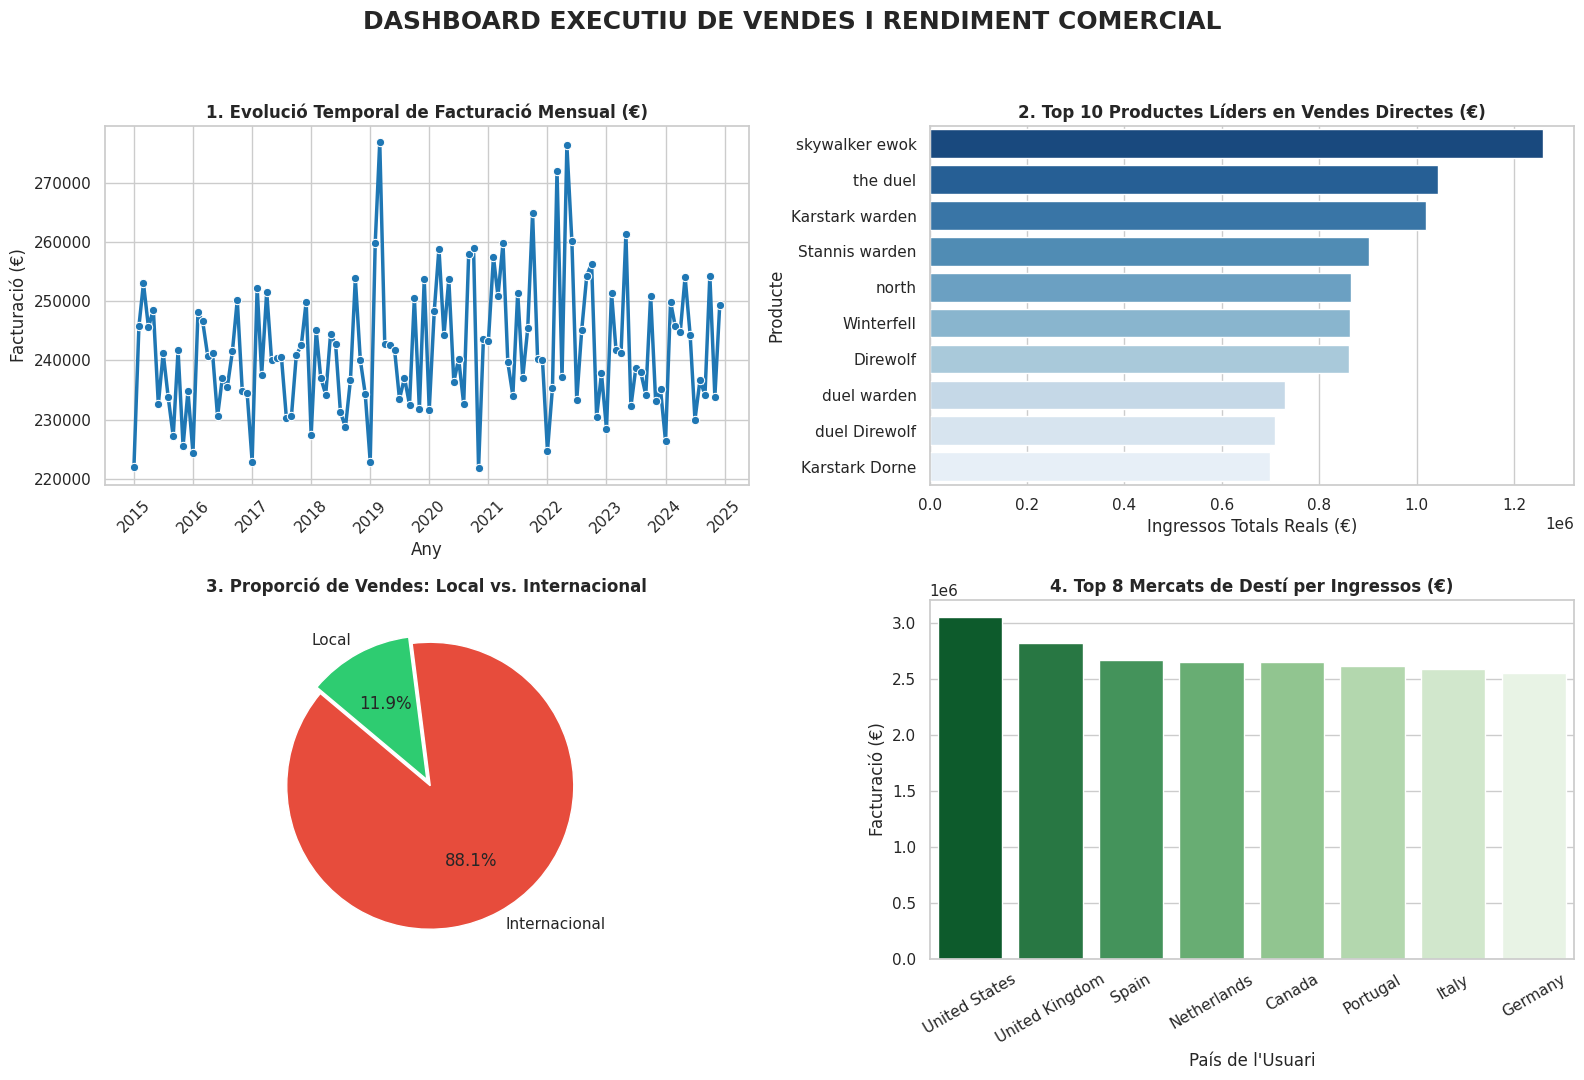

In [35]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración del estilo ejecutivo
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Preparación de datos válidos (Ventas Reales Aprobadas)
df_valid = df_transactions[df_transactions["declined"] == 0].copy()
df_valid["timestamp"] = pd.to_datetime(df_valid["timestamp"])
df_valid["mes_año"] = df_valid["timestamp"].dt.to_period("M").astype(str)

# Uniones con empresas y usuarios, adecuamos country de cada origen
df_dash = pd.merge(
    df_valid,
    df_companies[["company_id", "country"]].rename(
        columns={"country": "pais_empresa"}
    ),
    left_on="business_id",
    right_on="company_id",
    how="left",
)
df_dash = pd.merge(
    df_dash,
    df_users[["id", "country"]].rename(columns={"country": "pais_usuario"}),
    left_on="user_id",
    right_on="id",
    how="left",
)
# Indicador de Local/Internacional Bool
df_dash["es_local"] = df_dash["pais_empresa"] == df_dash["pais_usuario"]

# Desanidado de productos para el gráfico 2
df_dash["product_id_list"] = (
    df_dash["product_ids"].astype(str).str.split(",")
)
df_dash_exp = df_dash.explode("product_id_list")
df_dash_exp["product_id"] = pd.to_numeric(
    df_dash_exp["product_id_list"].str.strip(), errors="coerce"
)
# Incorporamos los datos de producto
df_dash_prod = pd.merge(
    df_dash_exp,
    df_products[["id", "product_name", "price"]],
    left_on="product_id",
    right_on="id",
    how="left",
)

# Creación de la figura 2x2 para el Dashboard Ejecutivo
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "DASHBOARD EXECUTIU DE VENDES I RENDIMENT COMERCIAL",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

# Visualización 1: Evolución Temporal de Ventas Mensuales (€)
ventas_mes = df_dash.groupby("mes_año")["amount"].sum().reset_index()
ventas_mes["mes_año"] = pd.to_datetime(ventas_mes["mes_año"], format="%Y-%m")

sns.lineplot(
    data=ventas_mes,
    x="mes_año",
    y="amount",
    ax=axes[0, 0],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
)
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 0].set_title(
    "1. Evolució Temporal de Facturació Mensual (€)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Any")
axes[0, 0].set_ylabel("Facturació (€)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Visualización 2: Top 10 Productos por Facturación Real (€)
top_prod = (
    df_dash_prod.groupby("product_name")["price"]
    .sum()
    .nlargest(10)
    .reset_index()
)
sns.barplot(
    data=top_prod,
    x="price",
    y="product_name",
    ax=axes[0, 1],
    palette="Blues_r",
    hue="product_name",
    legend=False,
)
axes[0, 1].set_title(
    "2. Top 10 Productes Líders en Vendes Directes (€)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Ingressos Totals Reals (€)")
axes[0, 1].set_ylabel("Producte")

# Visualización 3: Distribución del Gasto Local vs Internacional
tipo_compra = (
    df_dash["es_local"]
    .map({True: "Local", False: "Internacional"})
    .value_counts()
)
axes[1, 0].pie(
    tipo_compra,
    labels=tipo_compra.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#e74c3c", "#2ecc71"],
    explode=(0.05, 0),
)
axes[1, 0].set_title(
    "3. Proporció de Vendes: Local vs. Internacional",
    fontsize=12,
    fontweight="bold",
)

# Visualización 4: Facturación por País del Comprador
ventas_pais = (
    df_dash.groupby("pais_usuario")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)
sns.barplot(
    data=ventas_pais,
    x="pais_usuario",
    y="amount",
    ax=axes[1, 1],
    palette="Greens_r",
    hue="pais_usuario",
    legend=False,
)
axes[1, 1].set_title(
    "4. Top 8 Mercats de Destí per Ingressos (€)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("País de l'Usuari")
axes[1, 1].set_ylabel("Facturació (€)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 2. Dashboard interactiu amb Streamlit

Construcció d'una aplicació simple amb Streamlit, orientada a exploració interactiva.

Requisits:

- 1 pàgina Streamlit   
Almenys:  
- 2 filtres
- 3-4 visualitzacions
- Ús de st.sidebar o selectors

### 3. Dashboard amb Dash

Construcció d'un dashboard web amb Plotly Dash.

Requisits:

- Layout amb components.
- Callbacks simples.
- Almenys 3 visualitzacions connectades.

## Exercici 2: Informe executiu
🎯 Objectiu: A partir del dashboard, presenta un informe executiu en dues versions:

L'informe ha de contenir obligatòriament:

1. Resum general (màx. 5 línies): Què s'ha analitzat i amb quin objectiu.

2. Troballes clau (3-5): Insights sòlids basats en dades reals.

3. Riscos detectats: Per exemple: dependència excessiva de productes o empreses, manca de captació de nous usuaris, franges horàries crítiques, possibles indicis de frau o anomalies...

4. Oportunitats: millores operatives, segments no explotats, productes o franges amb potencial, optimització de recursos...

5. Recomanacions: Accions concretes i no tècniques, orientades a negoci.

### Sense IA:

Redactada amb les teves pròpies paraules.

#### INFORME EJECUTIVO DE RENDIMIENTO COMERCIAL Y VENTAS

---

### Resumen General

Hemos analizado el histórico de ventas y transacciones de la empresa para el periodo **2015-2024**. Se han estudiado el volumen de ingresos, la procedencia de los clientes, la estacionalidad a lo largo del año, el comportamiento de los usuarios y la estabilidad de los pagos. El objetivo de este análisis es diagnosticar el estado actual del negocio, señalar los principales problemas comerciales u operativos y proponer recomendaciones claras para mejorar la rentabilidad.

---

### Hallazgos Clave

* **Dependencia de mercados europeos y exportación:**
  * La gran mayoría de los ingresos (**88,1%**) proviene del mercado internacional.
  * Cinco países europeos concentran más del **73%** de las ventas totales: **Suecia** (*16,8%*), **Países Bajos** (*15,4%*), **Reino Unido** (*14,0%*), **Italia** (*14,0%*) y **Alemania** (*13,7%*).

* **Concentración en productos de gama alta:**
  * La facturación depende en gran medida de unos pocos productos estrella de precio elevado, como *the duel* (*con más de 3,5 M€ acumulados*), *Winterfell*, *skywalker ewok* y *dooku solo*.
  * El importe medio por compra en estos productos suele moverse entre los **300 € y los 500 €**.

* **Patrón de estacionalidad marcado y regular:**
  * Las ventas siguen un ciclo muy claro año tras año: se alcanzan picos de facturación en primavera (*marzo y mayo, superando los 260.000 € - 280.000 € mensuales*) y se registra una caída notable durante el mes de noviembre (*alrededor de los 230.000 €*).

* **Ventas muy repartidas por días y franjas:**
  * La actividad comercial está hiperestable durante toda la semana, moviéndose entre el **13,99%** los lunes y el **14,43%** los jueves.
  * Pasa lo mismo con las franjas horarias (*mañana, tarde y noche*), que registran un volumen de operaciones prácticamente constante (*~3.300 - 3.450 compras anuales por bloque*).

* **Pocos clientes mueven mucho volumen:**
  * Existe una alta concentración de la facturación (1.5%) en un grupo reducido de compradores.
  * Los usuarios con ID `289` y `318` encabezan la lista con alrededor de **47.000 €** gastados cada uno.

---

### Riesgos Detectados

* **Poco movimiento en el mercado local (*fuga internacional*):**
  * El mercado nacional solo representa un **11,9%** del total de las ventas. Esto muestra que la mayoría de los clientes locales compran a través de filiales o distribuidores externos en lugar de hacerlo directamente.

* **Raros picos de rechazos / Riesgo de fraude nocturno:**
  * Al analizar las compras denegadas por horas, se ve algo raro en la franja nocturna y de madrugada (*de 22 h a 8 h*).
  * Hay picos de rechazos con importes muy altos (*de 350 € a 500 €*) que igualan o superan a las compras aceptadas, lo que apunta a bots (*fraude automatizado*).

* **Falta de captación en productos base:**
  * La mayoría de artículos del catálogo están en estado "Estancado" o "Recurrente" (*generan pocos ingresos y atraen pocos clientes nuevos*). Atraer gente nueva depende casi al 100% de los productos estrella.

* **Depender demasiado de los clientes VIP:**
  * El Top 15 de compradores representa una parte enorme de los ingresos totales. Perder a clientes clave como el `289`, `318` o `455` dañaría significativament el balance global.

---

### Oportunidades

* **Reactivación del mercado local:**
  * Hay un margen enorme para crecer en el mercado nacional (*partiendo del 11,9% actual*) mediante ofertas específicas, mejor posicionamiento y ajustando gastos de envío.

* **Impulsar productos secundarios con packs:**
  * Se pueden crear combos (*packs de productos*) que junte los superventas (*the duel*, *Winterfell*) con artículos secundarios para dar salida a estos últimos.

* **Evitar la bajada de noviembre:**
  * Diseñar promociones potentes de otoño o adelantar campañas navideñas para contrarrestar el valle habitual de ventas en noviembre.

* **Sistemas e infraestructura 24/7:**
  * Como la demanda no para ni de noche ni los fines de semana, la pasarela de cobro, la logística y la atención al cliente tienen que rendir al 100% sin interrupciones.

---

### Recomendaciones de Negocio

1. **Revisar los filtros de fraude en la pasarela de pago:**
   * Auditar las reglas de cobro en la franja nocturna (*de 22 h a 7 h*) para no eliminar transacciones de clientes legítimos y frenar mejor los ataques de bots.

2. **Plan de fidelización para clientes Key Account:**
   * Crear un programa de fidelización y trato exclusivo enfocado en el Top 15 de compradores para asegurar que se queden con nosotros a largo plazo.

3. **Estrategia de penetración en el mercado local:**
   * Lanzar campañas de marketing específicas para captar más ventas directas dentro del territorio nacional.

4. **Ajustar el stock a la estacionalidad:**
   * Aumentar el inventario entre febrero y mayo para cubrir los picos de primavera, y activar promociones potentes en noviembre para estabilizar los ingresos.

###  Amb suport d'IA:

Utilitzant eines d'IA per:

- Millorar la redacció.
- Adaptar el llenguatge al departament escollit.
- Incorporar vocabulari tècnic de negoci.

#### 1. Resumen general con IA

Este informe recoge el análisis exhaustivo de la base de datos comercial y operativa correspondiente al periodo 2015-2024. La evaluación combina métricas de facturación, volumen de transacciones, comportamiento de los usuarios, eficiencia geográfica y patrones temporales (horarios, diarios y mensuales). El objetivo principal es ofrecer a la dirección ejecutiva una visión clara sobre los pilares del negocio, evaluar los puntos de estrés operativo y definir acciones estratégicas para mejorar la rentabilidad y mitigar riesgos.

---

### 2. Hallazgos clave

#### A. Geografía y Mercados

* **Dependencia exterior:** Más del $88\%$ de la facturación proviene de exportaciones internacionales.
* **Concentración en Europa central y del norte:** Según la distribución de Pareto y el Treemap, Suecia ($16,8\%$), Países Bajos ($15,4\%$), Reino Unido ($14,0\%$), Italia ($14,0\%$) y Alemania ($13,7\%$) representan cerca del $74\%$ de la facturación global.

#### B. Catálogo y Rendimiento de Producto

* **Liderazgo claro de la gama alta:** *the duel* lidera la facturación absoluta ($>3,5\text{M}€$), seguido de cerca por *Winterfell*, *skywalker ewok* y *dooku solo*.
* **Estabilidad en el importe transaccional:** La mayoría de los 15 productos más vendidos tienen una mediana de importe por transacción situada entre los $300€$ y los $450€$, con un techo habitual en torno a los $800€$-$1.000€$ en operaciones atípicas.

#### C. Comportamiento Temporal y Estacionalidad

* **Comportamiento diario uniforme:** La facturación se distribuye de manera prácticamente simétrica durante los 7 días de la semana, oscilando entre $4,06\text{M}€$ el lunes ($13,99\%$) y $4,18\text{M}€$ el jueves ($14,43\%$).
* **Actividad ininterrumpida:** Las franjas horarias (mañana, tarde, noche) presentan niveles de actividad muy similares a lo largo de los años.
* **Ciclos mensuales definidos:** Se detectan de forma sistémica dos grandes picos de facturación anuales en primavera (marzo y mayo) y un descenso pronunciado durante el otoño (especialmente en noviembre).

---

### 3. Riesgos detectados

| Riesgo | Impacto en el Negocio |
| --- | --- |
| **1. Elevado porcentaje de fallos en pagos nocturnos** | Posible intento de fraude o pérdida de ingresos por problemas en la pasarela. |
| **2. Vulnerabilidad por concentración de grandes usuarios (Top 15)** | Elevada dependencia de un grupo reducido de clientes clave. |
| **3. Debilidad del mercado local (solo un 11,9% de ventas)** | Vulnerabilidad ante cambios en aranceles o costes de transporte internacional. |
| **4. Estancamiento en la captación de nuevos usuarios para productos secundarios** | Dificultad para renovar la base de clientes con los productos secundarios. |

1. **Anomalías en la pasarela de pagos (Horario nocturno/madrugada):** El análisis de las transacciones rechazadas en comparación con las aceptadas demuestra que entre las 22 h y las 8 h se producen denegaciones con importes muy elevados (mediana alrededor de los $350€$-$500€$). Esto sugiere operaciones de ataques automatizados de validación de tarjetas robadas o reglas de riesgo demasiado rígidas que están bloqueando a compradores legítimos.
2. **Dependencia de cuentas clave (Key Accounts):** El análisis de Pareto de usuarios indica que los usuarios `289` y `318` generan aproximadamente $47.000€$ cada uno. La pérdida de esta lista reducida de clientes afectaría inmediatamente al volumen de negocio.
3. **Escasa presencia en el mercado doméstico:** Menos de un $12\%$ de la facturación proviene del mercado local. Esto expone a la compañía a riesgos regulatorios, de transporte internacional o fluctuaciones en el comercio exterior.

---

### 4. Oportunidades

1. **Desarrollo y potenciación del mercado local:** Diseñar una propuesta de valor adaptada al territorio nacional para reducir la fuga de compradores locales hacia proveedores o canales externos.
2. **Optimización de la conversión nocturna:** Ajustar las reglas del sistema antifraude y mejorar la experiencia de pago para recuperar las opciones de venta fallidas en horario de madrugada.
3. **Campañas de desestacionalización en noviembre:** Lanzar estrategias promocionales o de venta anticipada en el cuarto trimestre para aumentar los ingresos en los meses históricamente más débiles.
4. **Empaquetado de productos (Cross-selling):** Utilizar la posición dominante de los productos "Captadores" (*the duel*, *Winterfell*) para impulsar los productos clasificados como "Estancados" o "Emergentes" mediante packs combinados.

---

### 5. Recomendaciones estratégicas y operatividad de negocio

1. **Optimización del proceso de cobro y seguridad:**
* Revisar con el proveedor de la pasarela de pago las reglas de bloqueo para transacciones realizadas fuera del horario comercial habitual.
* Integrar herramientas de validación en tiempo real (como 3D Secure dinámico) para reducir la tasa de denegación en operaciones de alto valor durante la noche.


2. **Estrategia comercial y plan de fidelización B2B/VIP:**
* Diseñar un programa de fidelización y atención exclusiva dirigido al Top 15 de usuarios compradores para garantizar su recurrencia y contratos plurianuales.
* Establecer alertas comerciales si un cliente de alto volumen reduce su frecuencia de compra habitual.


3. **Reorientación del marketing y distribución geográfica:**
* Concentrar el presupuesto de inversión publicitaria en los 5 principales mercados europeos (Suecia, Países Bajos, Reino Unido, Italia y Alemania), donde la tasa de conversión es más alta.
* Crear una campaña específica para el mercado local que elimine las desventajas competitivas en costes de envío o tiempos de entrega.


4. **Ajuste logístico y de gestión de stocks:**
* Adaptar las líneas de producción y almacén a los picos de demanda primaverales (marzo/mayo), evitando la rotura de stock (*stockout*) durante estos meses de alta actividad.
* Mantener la capacidad logística activa de manera uniforme durante todos los días de la semana, dada la constancia de las ventas de lunes a domingo.